# Analiza najboljih rezultata klasterovanja

U ovom notebook-u ponovo se pokreću najbolje konfiguracije algoritama
za svaku verziju skupa podataka.

Za svaki skup koriste se tri klastera, a izabrani algoritmi su:

| Skup | Algoritam |
|---|---|
| X_full | Spectral Clustering |
| X_top30 | Spectral Clustering |
| X_player_only | Spectral Clustering |
| X_pca90 | Hijerarhijsko klasterovanje |
| X_no_countries | Hijerarhijsko klasterovanje |
| X_no_countries_no_club | Hijerarhijsko klasterovanje |
| X_no_countries_no_club_pca95 | Hijerarhijsko klasterovanje |

Zbog računarske zahtevnosti oba algoritma pokreću se nad stratifikovanim
uzorkom od 10.000 igrača.

Dobijeni klasteri analiziraju se prema poziciji, broju utakmica,
minutaži, golovima, asistencijama, ulozi startera, izmene i kapitena,
tržišnoj vrednosti i drugim dostupnim karakteristikama.

In [10]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import (
    SpectralClustering,
    AgglomerativeClustering
)

from sklearn.model_selection import train_test_split

from IPython.display import display

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
N_CLUSTERS = 3

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [13]:
CLUSTER_DIR = Path("../data/processed/clusters")
PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results/cluster_analysis")

LABELS_DIR = RESULTS_DIR / "labels"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

LABELS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
X_full = pd.read_csv(
    CLUSTER_DIR / "X_full.csv"
)

X_top30 = pd.read_csv(
    CLUSTER_DIR / "X_top30.csv"
)

X_player_only = pd.read_csv(
    CLUSTER_DIR / "X_player_only.csv"
)

X_pca90 = pd.read_csv(
    CLUSTER_DIR / "X_pca90.csv"
)

X_no_countries = pd.read_csv(
    CLUSTER_DIR / "X_no_countries.csv"
)

X_no_countries_no_club = pd.read_csv(
    CLUSTER_DIR / "X_no_countries_no_club.csv"
)

X_no_countries_no_club_pca95 = pd.read_csv(
    CLUSTER_DIR / "X_no_countries_no_club_pca95.csv"
)

In [16]:
players_analysis = pd.read_csv(
    PROCESSED_DIR / "player_features_full.csv"
)

In [17]:
datasets = {
    "X_full": X_full,
    "X_top30": X_top30,
    "X_player_only": X_player_only,
    "X_pca90": X_pca90,
    "X_no_countries": X_no_countries,
    "X_no_countries_no_club": X_no_countries_no_club,
    "X_no_countries_no_club_pca95": X_no_countries_no_club_pca95
}

for name, X in datasets.items():
    print(
        name,
        X.shape,
        "OK" if len(X) == len(players_analysis) else "NEUSKLAĐENO"
    )

X_full (44905, 352) OK
X_top30 (44905, 183) OK
X_player_only (44905, 177) OK
X_pca90 (44905, 82) OK
X_no_countries (44905, 152) OK
X_no_countries_no_club (44905, 114) OK
X_no_countries_no_club_pca95 (44905, 55) OK


In [18]:
def create_stratified_sample(
    X,
    players_df,
    sample_size=10_000,
    stratify_column="position",
    random_state=42
):
    if len(X) != len(players_df):
        raise ValueError(
            "Matrica atributa i tabela igrača nemaju isti broj redova."
        )

    if sample_size >= len(players_df):
        sample_indices = np.arange(len(players_df))
    else:
        all_indices = np.arange(len(players_df))

        sample_indices, _ = train_test_split(
            all_indices,
            train_size=sample_size,
            stratify=players_df[stratify_column],
            random_state=random_state
        )

    if isinstance(X, pd.DataFrame):
        X_sample = X.iloc[sample_indices].to_numpy()
    else:
        X_sample = np.asarray(X)[sample_indices]

    players_sample = (
        players_df
        .iloc[sample_indices]
        .copy()
        .reset_index(drop=True)
    )

    return X_sample, players_sample, sample_indices

In [19]:
def run_clustering(
    X,
    algorithm,
    n_clusters=3
):
    if algorithm == "spectral":
        model = SpectralClustering(
            n_clusters=n_clusters,
            affinity="nearest_neighbors",
            n_neighbors=10,
            assign_labels="kmeans",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif algorithm == "hierarchical":
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage="ward"
        )

    else:
        raise ValueError(
            f"Nepoznat algoritam: {algorithm}"
        )

    labels = model.fit_predict(X)

    return model, labels

In [20]:
def analyze_clusters(
    players_df,
    labels,
    dataset_name,
    save_results=True
):
    clustered_players = players_df.copy()
    clustered_players["cluster"] = labels

    dataset_tables_dir = TABLES_DIR / dataset_name
    dataset_figures_dir = FIGURES_DIR / dataset_name

    dataset_tables_dir.mkdir(parents=True, exist_ok=True)
    dataset_figures_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print(f"ANALIZA SKUPA: {dataset_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Veličine klastera
    # --------------------------------------------------------

    cluster_sizes = (
        clustered_players["cluster"]
        .value_counts()
        .sort_index()
        .rename("broj_igraca")
        .to_frame()
    )

    cluster_sizes["udeo_igraca"] = (
        cluster_sizes["broj_igraca"]
        / len(clustered_players)
        * 100
    )

    print("\nVeličine klastera:")
    display(cluster_sizes.round(2))

    plt.figure(figsize=(8, 5))

    plt.bar(
        cluster_sizes.index.astype(str),
        cluster_sizes["broj_igraca"]
    )

    plt.xlabel("Klaster")
    plt.ylabel("Broj igrača")
    plt.title(f"Broj igrača po klasterima — {dataset_name}")
    plt.tight_layout()

    if save_results:
        plt.savefig(
            dataset_figures_dir / "cluster_sizes.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    # --------------------------------------------------------
    # 2. Numerički profil klastera
    # --------------------------------------------------------

    numeric_columns = [
        "age",
        "height_in_cm",
        "international_caps",
        "international_goals",
        "market_value_in_eur",
        "highest_market_value_in_eur",
        "matches_played",
        "total_minutes",
        "average_minutes",
        "maximum_minutes",
        "minutes_std",
        "total_goals",
        "total_assists",
        "starter_count",
        "substitute_count",
        "captain_count",
        "starter_percentage",
        "substitute_percentage",
        "captain_percentage",
        "valuation_count",
        "valuation_mean",
        "valuation_min",
        "valuation_max",
        "first_valuation",
        "latest_valuation",
        "valuation_growth",
        "valuation_growth_percentage"
    ]

    available_numeric_columns = [
        column
        for column in numeric_columns
        if column in clustered_players.columns
    ]

    numeric_profile_mean = (
        clustered_players
        .groupby("cluster")[available_numeric_columns]
        .mean()
        .round(3)
    )

    numeric_profile_median = (
        clustered_players
        .groupby("cluster")[available_numeric_columns]
        .median()
        .round(3)
    )

    print("\nProsečne vrednosti atributa po klasterima:")
    display(numeric_profile_mean)

    print("\nMedijane atributa po klasterima:")
    display(numeric_profile_median)

    # --------------------------------------------------------
    # 3. Raspodela glavnih pozicija
    # --------------------------------------------------------

    categorical_distributions = {}

    categorical_columns = [
        "position",
        "sub_position",
        "foot",
        "country_of_birth",
        "country_of_citizenship"
    ]

    for column in categorical_columns:
        if column not in clustered_players.columns:
            continue

        distribution = pd.crosstab(
            clustered_players["cluster"],
            clustered_players[column].fillna("Unknown"),
            normalize="index"
        ) * 100

        categorical_distributions[column] = distribution

        print(f"\nRaspodela atributa '{column}' po klasterima (%):")
        display(distribution.round(2))

    if "position" in categorical_distributions:
        position_distribution = categorical_distributions["position"]

        ax = position_distribution.plot(
            kind="bar",
            stacked=True,
            figsize=(11, 6)
        )

        ax.set_xlabel("Klaster")
        ax.set_ylabel("Udeo igrača (%)")
        ax.set_title(
            f"Raspodela pozicija po klasterima — {dataset_name}"
        )

        ax.legend(
            title="Pozicija",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout()

        if save_results:
            plt.savefig(
                dataset_figures_dir / "position_distribution.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    # --------------------------------------------------------
    # 4. Raspodele numeričkih atributa
    # --------------------------------------------------------

    plot_columns = [
        "age",
        "market_value_in_eur",
        "matches_played",
        "total_minutes",
        "average_minutes",
        "total_goals",
        "total_assists",
        "starter_percentage",
        "substitute_percentage",
        "captain_percentage"
    ]

    available_plot_columns = [
        column
        for column in plot_columns
        if column in clustered_players.columns
    ]

    cluster_labels = sorted(
        clustered_players["cluster"].unique()
    )

    for column in available_plot_columns:
        values_by_cluster = [
            clustered_players.loc[
                clustered_players["cluster"] == cluster,
                column
            ].dropna()
            for cluster in cluster_labels
        ]

        plt.figure(figsize=(9, 5))

        plt.boxplot(
            values_by_cluster,
            tick_labels=[
                str(cluster)
                for cluster in cluster_labels
            ],
            showfliers=False
        )

        plt.xlabel("Klaster")
        plt.ylabel(column)
        plt.title(
            f"Raspodela atributa {column} — {dataset_name}"
        )

        plt.tight_layout()

        if save_results:
            plt.savefig(
                dataset_figures_dir / f"{column}.png",
                dpi=300,
                bbox_inches="tight"
            )

        plt.show()

    # --------------------------------------------------------
    # 5. Najčešće kategorije po klasterima
    # --------------------------------------------------------

    summary_rows = []

    for cluster in cluster_labels:
        cluster_data = clustered_players[
            clustered_players["cluster"] == cluster
        ]

        row = {
            "cluster": cluster,
            "broj_igraca": len(cluster_data),
            "udeo_igraca": (
                len(cluster_data)
                / len(clustered_players)
                * 100
            )
        }

        for column in available_numeric_columns:
            row[f"mean_{column}"] = cluster_data[column].mean()

        for column in categorical_columns:
            if column not in cluster_data.columns:
                continue

            mode = cluster_data[column].dropna().mode()

            row[f"najcesci_{column}"] = (
                mode.iloc[0]
                if len(mode) > 0
                else np.nan
            )

        summary_rows.append(row)

    cluster_summary = pd.DataFrame(summary_rows)

    print("\nSažetak klastera:")
    display(cluster_summary.round(3))

    # --------------------------------------------------------
    # 6. Čuvanje rezultata
    # --------------------------------------------------------

    if save_results:
        clustered_players.to_csv(
            dataset_tables_dir / "players_with_clusters.csv",
            index=False
        )

        cluster_sizes.to_csv(
            dataset_tables_dir / "cluster_sizes.csv"
        )

        numeric_profile_mean.to_csv(
            dataset_tables_dir / "numeric_profile_mean.csv"
        )

        numeric_profile_median.to_csv(
            dataset_tables_dir / "numeric_profile_median.csv"
        )

        cluster_summary.to_csv(
            dataset_tables_dir / "cluster_summary.csv",
            index=False
        )

        for column, distribution in categorical_distributions.items():
            distribution.to_csv(
                dataset_tables_dir
                / f"{column}_distribution.csv"
            )

    return {
        "players": clustered_players,
        "cluster_sizes": cluster_sizes,
        "numeric_profile_mean": numeric_profile_mean,
        "numeric_profile_median": numeric_profile_median,
        "categorical_distributions": categorical_distributions,
        "cluster_summary": cluster_summary
    }

In [21]:
def run_best_clustering_and_analysis(
    X,
    players_df,
    dataset_name,
    algorithm,
    sample_size=10_000
):
    """
    Formira stratifikovani uzorak, pokreće najbolji algoritam,
    čuva oznake klastera i izvršava analizu.
    """

    print(f"\nPokretanje skupa: {dataset_name}")
    print(f"Algoritam: {algorithm}")
    print(f"Broj klastera: {N_CLUSTERS}")

    X_sample, players_sample, sample_indices = (
        create_stratified_sample(
            X=X,
            players_df=players_df,
            sample_size=sample_size,
            stratify_column="position",
            random_state=RANDOM_STATE
        )
    )

    print(f"Dimenzije uzorka: {X_sample.shape}")

    model, labels = run_clustering(
        X=X_sample,
        algorithm=algorithm,
        n_clusters=N_CLUSTERS
    )

    labels_df = pd.DataFrame({
        "original_index": sample_indices,
        "player_id": (
            players_sample["player_id"]
            if "player_id" in players_sample.columns
            else np.nan
        ),
        "cluster": labels
    })

    labels_df.to_csv(
        LABELS_DIR / f"{dataset_name}_labels.csv",
        index=False
    )

    analysis = analyze_clusters(
        players_df=players_sample,
        labels=labels,
        dataset_name=dataset_name,
        save_results=True
    )

    return {
        "model": model,
        "labels": labels,
        "sample_indices": sample_indices,
        "players_sample": players_sample,
        "analysis": analysis
    }


Pokretanje skupa: X_full
Algoritam: spectral
Broj klastera: 3
Dimenzije uzorka: (10000, 352)


/home/janic/projects/ip2-football-players/venv-ip2/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


ANALIZA SKUPA: X_full

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,9978,99.780
1,11,0.110
2,11,0.110


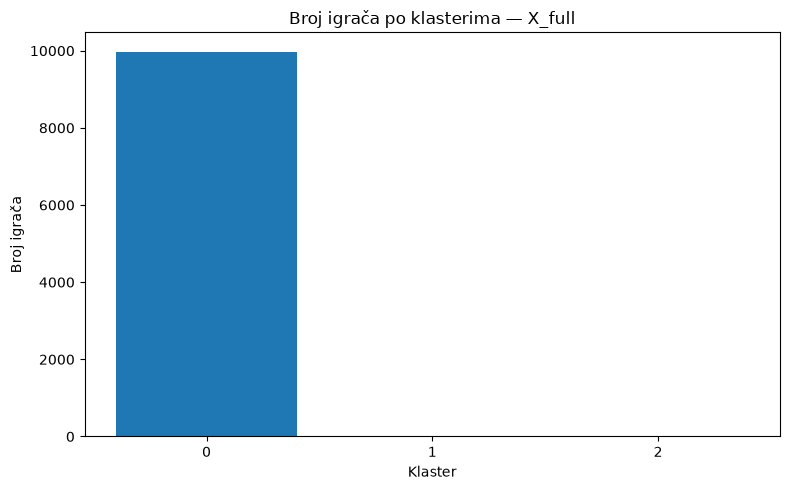


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,29.536,182.181,3.332,0.376,"1,344,804.069","3,089,477.851",41.139,"2,833.156",14.190,3.839,3.053,31.335,23.782,2.654,13.676,"266,592.002","1,344,804.069","1,078,212.067"
1,32.403,182.727,19.000,2.636,"1,263,636.364","3,300,000.000",71.364,"4,202.636",22.832,15.182,4.909,48.000,45.091,0.091,17.182,"40,909.091","1,263,636.364","1,222,727.273"
2,33.458,185.091,11.182,0.455,"325,909.091","1,136,363.636",23.273,"1,349.091",23.736,3.909,1.455,22.182,20.545,2.636,20.182,"77,272.727","325,909.091","248,636.364"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,28.770,182.000,0.000,0.000,"200,000.000","600,000.000",5.000,180.000,10.613,0.000,0.000,6.000,10.000,0.000,12.000,"75,000.000","200,000.000","75,000.000"
1,33.060,184.000,0.000,0.000,"400,000.000","2,000,000.000",7.000,367.000,28.207,0.000,0.000,14.000,11.000,0.000,20.000,"25,000.000","400,000.000","350,000.000"
2,31.880,187.000,0.000,0.000,"200,000.000","1,400,000.000",18.000,869.000,26.750,1.000,1.000,16.000,22.000,0.000,22.000,"50,000.000","200,000.000","125,000.000"



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,10.580,3.760,22.700,62.960
1,0.000,9.090,9.090,81.820
2,0.000,9.090,18.180,72.730



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.100,0.070,0.140,3.990,0.020,0.700,0.830,0.010,0.020,0.120,2.060,0.030,0.020,0.400,5.310,0.160,0.030,0.030,0.350,0.470,0.280,0.100,0.020,0.020,0.220,0.040,1.800,0.050,0.090,0.630,0.950,0.020,0.080,0.350,0.080,1.700,0.010,0.010,0.040,0.270,0.020,4.370,0.010,0.080,0.020,0.040,0.270,5.610,0.030,0.030,0.150,4.300,0.680,2.560,0.060,0.210,0.140,0.010,0.050,0.050,0.220,0.210,0.010,0.090,0.020,0.400,0.230,4.350,0.070,1.750,0.020,1.160,0.030,0.060,1.250,0.010,0.030,0.020,0.070,0.010,0.020,0.010,0.010,0.110,0.010,0.020,0.010,0.150,0.020,0.020,0.010,1.020,0.070,0.020,0.140,0.030,3.390,0.030,0.010,0.100,0.010,0.010,0.930,0.250,0.960,0.010,0.070,0.010,0.250,0.020,0.140,0.010,1.090,2.660,0.010,1.080,2.130,0.030,0.080,0.420,1.810,0.690,0.200,0.410,0.090,0.290,0.330,0.030,0.120,4.740,0.010,0.010,0.010,1.130,0.830,0.010,0.030,0.010,0.130,0.080,0.030,0.110,2.880,0.020,1.230,1.970,0.050,2.460,0.020,1.480,10.680,0.770,0.020,0.250,0.010,0.100,0.890,0.200,0.040,0.060
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,72.730,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,27.270,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.350,0.310,0.190,0.030,3.870,0.080,0.020,1.070,0.870,0.080,0.020,0.010,0.260,2.870,0.070,0.030,0.620,5.450,0.160,0.130,0.060,0.500,0.340,0.200,0.070,0.010,0.240,0.070,2.210,0.050,0.160,0.100,0.690,1.360,0.020,0.170,0.090,1.110,0.420,2.800,0.030,0.300,0.010,0.010,3.700,0.060,0.010,0.100,0.010,0.060,0.290,4.090,0.020,0.050,0.220,3.370,0.810,3.040,0.030,0.090,0.250,0.150,0.030,0.100,0.060,0.280,0.290,0.030,0.100,0.030,0.650,0.270,4.520,0.130,1.880,0.020,0.030,0.030,1.440,0.290,0.010,0.050,0.010,0.040,0.020,0.010,0.000,0.040,0.070,0.020,0.010,0.410,0.030,0.080,0.030,0.020,1.070,0.090,0.260,0.020,0.620,0.040,3.290,0.010,0.010,0.170,0.040,1.270,0.220,0.240,1.260,0.020,0.020,0.010,0.070,0.010,0.290,0.150,0.030,1.290,2.790,0.030,1.300,3.220,0.050,1.060,2.230,0.900,1.860,0.010,0.090,0.380,0.430,0.020,0.110,0.010,4.650,0.020,0.010,0.180,1.660,0.890,0.010,0.010,0.020,0.010,0.230,0.100,0.070,0.210,3.290,0.010,1.550,0.070,3.600,0.010,1.340,0.680,0.790,0.050,0.250,0.010,0.230,0.060,0.040
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0

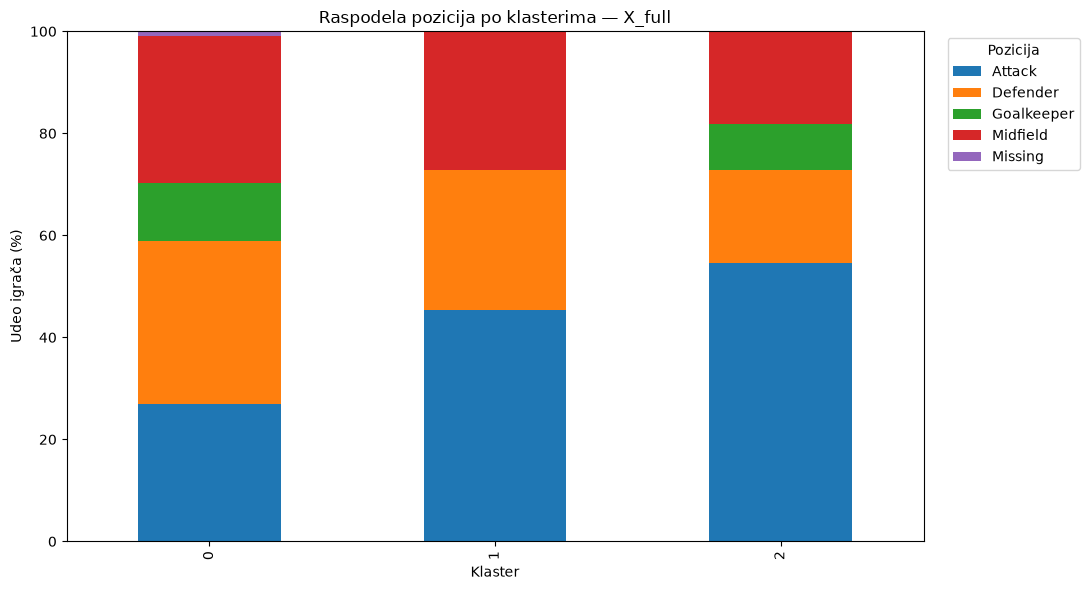

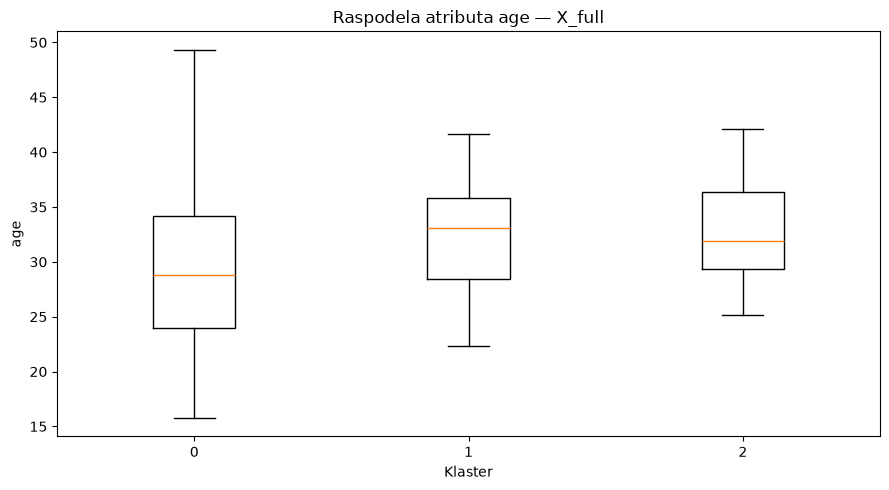

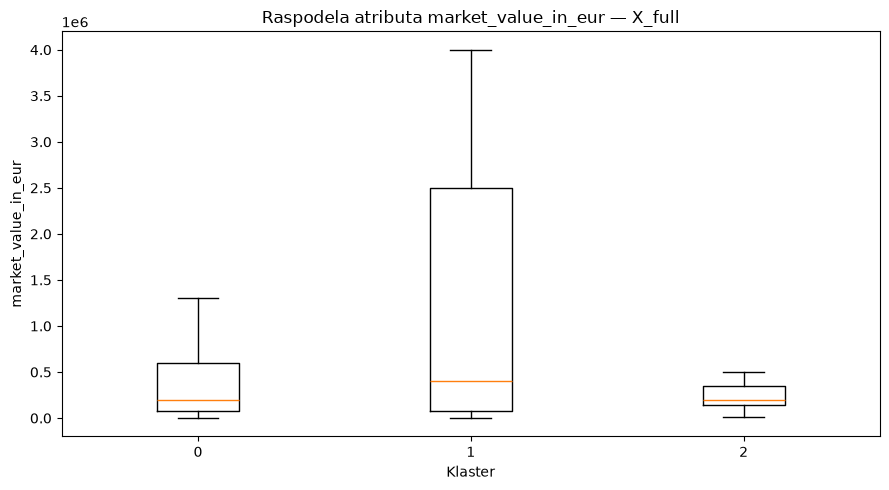

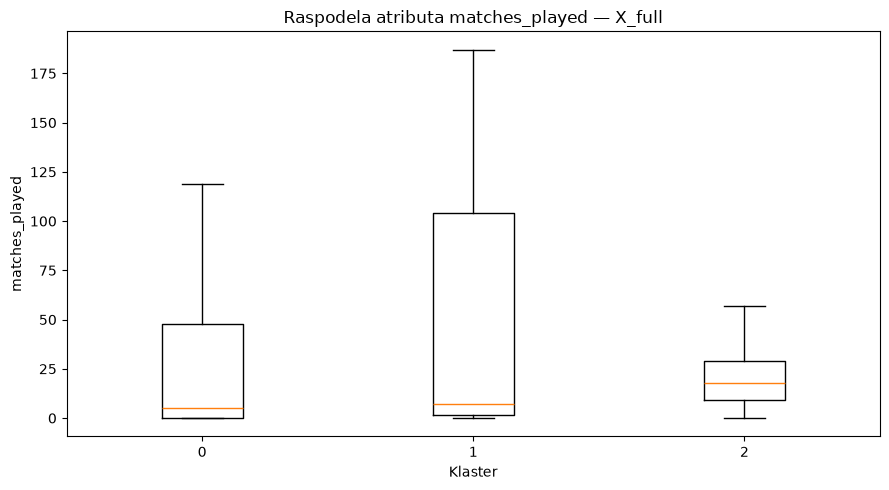

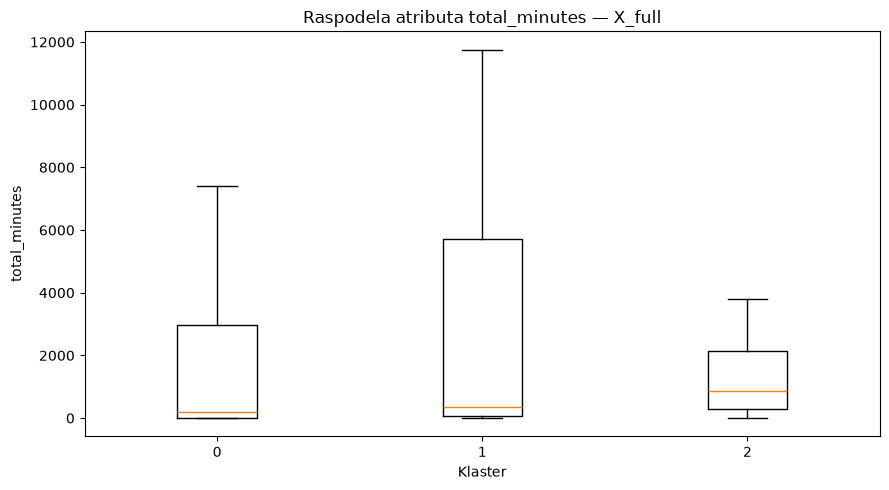

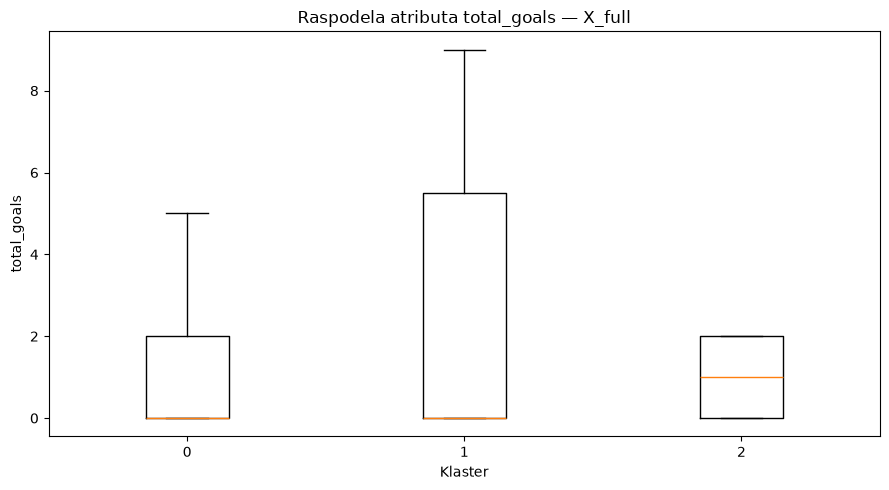

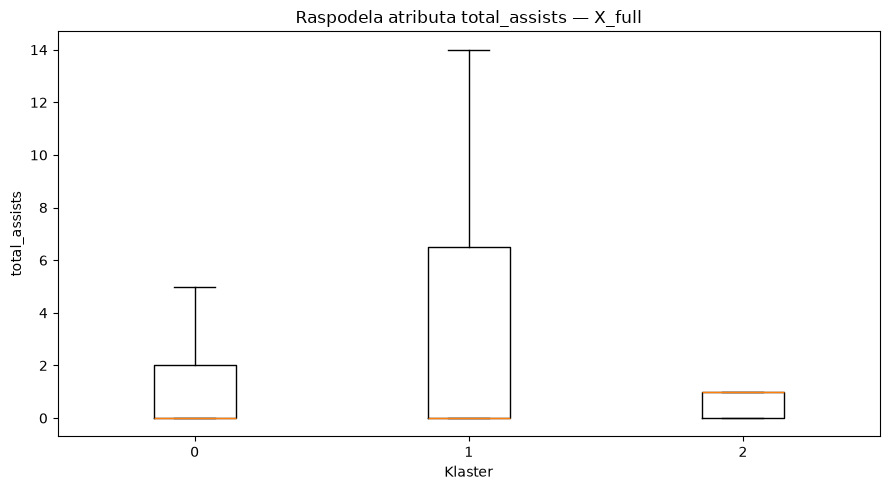


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,9978,99.780,29.536,182.181,3.332,0.376,"1,344,804.069","3,089,477.851",41.139,"2,833.156",14.190,3.839,3.053,31.335,23.782,2.654,13.676,"266,592.002","1,344,804.069","1,078,212.067",Defender,Centre-Back,right,France,Brazil
1,1,11,0.110,32.403,182.727,19.000,2.636,"1,263,636.364","3,300,000.000",71.364,"4,202.636",22.832,15.182,4.909,48.000,45.091,0.091,17.182,"40,909.091","1,263,636.364","1,222,727.273",Attack,Centre-Forward,right,Egypt,Egypt
2,2,11,0.110,33.458,185.091,11.182,0.455,"325,909.091","1,136,363.636",23.273,"1,349.091",23.736,3.909,1.455,22.182,20.545,2.636,20.182,"77,272.727","325,909.091","248,636.364",Attack,Centre-Forward,right,Lithuania,Lithuania


In [22]:
result_X_full = run_best_clustering_and_analysis(
    X=X_full,
    players_df=players_analysis,
    dataset_name="X_full",
    algorithm="spectral"
)


Pokretanje skupa: X_top30
Algoritam: spectral
Broj klastera: 3
Dimenzije uzorka: (10000, 183)


/home/janic/projects/ip2-football-players/venv-ip2/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


ANALIZA SKUPA: X_top30

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,9826,98.260
1,10,0.100
2,164,1.640


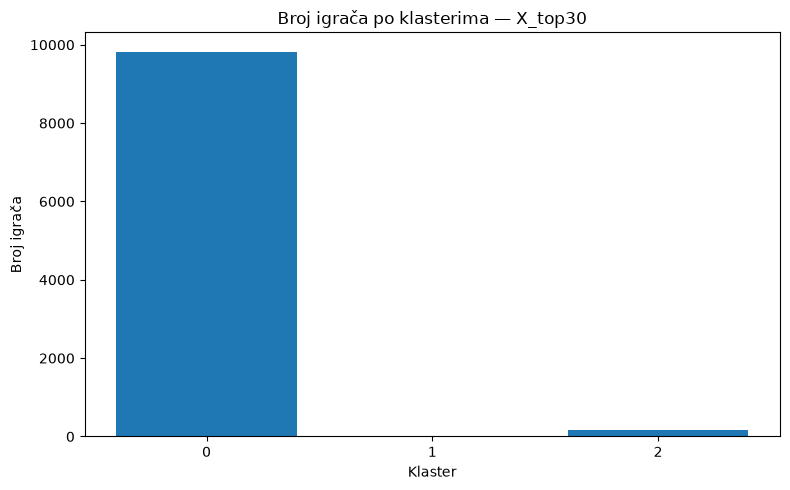


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,29.616,182.202,3.383,0.381,"1,360,674.740","3,133,491.248",41.780,"2,876.528",14.371,3.911,3.100,31.753,24.111,2.685,13.824,"269,881.437","1,360,674.740","1,090,793.303"
1,20.428,177.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,25.753,181.470,2.091,0.213,"402,134.146","523,932.927",6.110,399.610,5.417,0.518,0.476,8.750,6.756,0.732,6.317,"57,926.829","402,134.146","344,207.317"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,28.850,182.000,0.000,0.000,"200,000.000","600,000.000",5.000,207.500,11.582,0.000,0.000,6.000,11.000,0.000,13.000,"75,000.000","200,000.000","100,000.000"
1,19.310,176.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,23.660,182.000,0.000,0.000,"100,000.000","100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,3.000,"50,000.000","100,000.000",0.000



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,9.950,3.790,22.880,63.380
1,100.000,0.000,0.000,0.000
2,41.460,3.050,12.200,43.290



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.100,0.070,0.140,4.050,0.020,0.710,0.840,0.010,0.020,0.120,2.100,0.030,0.020,0.410,5.380,0.160,0.030,0.030,0.360,0.470,0.280,0.100,0.020,0.020,0.220,0.040,1.820,0.050,0.090,0.640,0.960,0.020,0.080,0.360,0.070,1.720,0.010,0.010,0.040,0.270,0.100,4.410,0.010,0.080,0.020,0.040,0.270,5.690,0.030,0.030,0.150,4.330,0.690,2.580,0.060,0.210,0.140,0.010,0.050,0.050,0.220,0.210,0.010,0.090,0.020,0.400,0.230,4.410,0.070,1.740,0.020,1.180,0.030,0.060,1.240,0.010,0.030,0.020,0.070,0.010,0.100,0.010,0.010,0.110,0.010,0.020,0.010,0.150,0.020,0.020,0.010,0.940,0.070,0.020,0.140,0.030,3.440,0.030,0.010,0.100,0.010,0.010,0.950,0.250,0.440,0.010,0.070,0.010,0.250,0.020,0.140,0.010,1.110,2.700,0.010,1.100,2.170,0.030,0.080,0.430,1.810,0.700,0.200,0.420,0.090,0.300,0.340,0.030,0.120,4.800,0.010,0.010,0.010,1.150,0.840,0.010,0.030,0.010,0.130,0.080,0.030,0.100,2.920,0.020,1.250,2.030,0.050,2.460,0.020,1.480,10.120,0.780,0.020,0.250,0.010,0.100,0.910,0.200,0.040,0.060
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,20.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,80.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.610,0.610,0.000,0.000,0.000,0.000,0.000,1.830,0.000,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,2.440,0.000,0.610,0.000,0.000,0.000,0.000,0.000,


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.360,0.320,0.190,0.020,3.930,0.080,0.020,1.080,0.890,0.080,0.020,0.010,0.260,2.850,0.070,0.030,0.630,5.520,0.160,0.130,0.060,0.500,0.350,0.200,0.070,0.010,0.240,0.070,2.110,0.050,0.160,0.100,0.690,1.370,0.020,0.170,0.090,1.130,0.430,2.840,0.030,0.310,0.120,0.010,3.730,0.060,0.010,0.100,0.010,0.060,0.300,4.140,0.020,0.050,0.220,3.410,0.820,3.020,0.030,0.090,0.250,0.150,0.030,0.100,0.060,0.280,0.300,0.030,0.100,0.030,0.650,0.270,4.580,0.130,1.870,0.020,0.030,0.030,1.350,0.280,0.010,0.050,0.010,0.040,0.010,0.010,0.110,0.040,0.070,0.020,0.010,0.420,0.030,0.080,0.030,0.020,0.990,0.090,0.260,0.020,0.620,0.040,3.340,0.010,0.010,0.170,0.040,1.290,0.220,0.240,0.480,0.020,0.020,0.010,0.070,0.010,0.300,0.150,0.030,1.310,2.830,0.030,1.320,3.260,0.050,1.060,2.220,0.920,1.890,0.010,0.090,0.390,0.440,0.020,0.110,0.010,4.710,0.020,0.010,0.180,1.630,0.910,0.010,0.010,0.020,0.010,0.230,0.100,0.070,0.190,3.330,0.010,1.570,0.070,3.590,0.010,1.330,0.690,0.800,0.050,0.250,0.010,0.230,0.060,0.040
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.000,3.660,0.000,0.000,0.000,1.220,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.000,0.000,8.540,0.000,0.000,0.000,0.610,0.610,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0

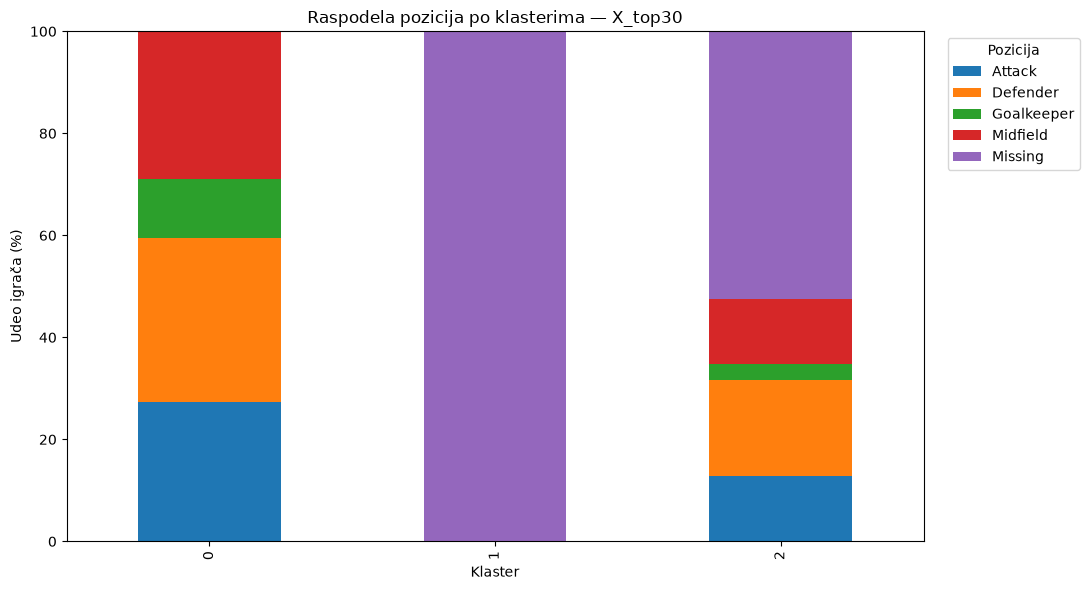

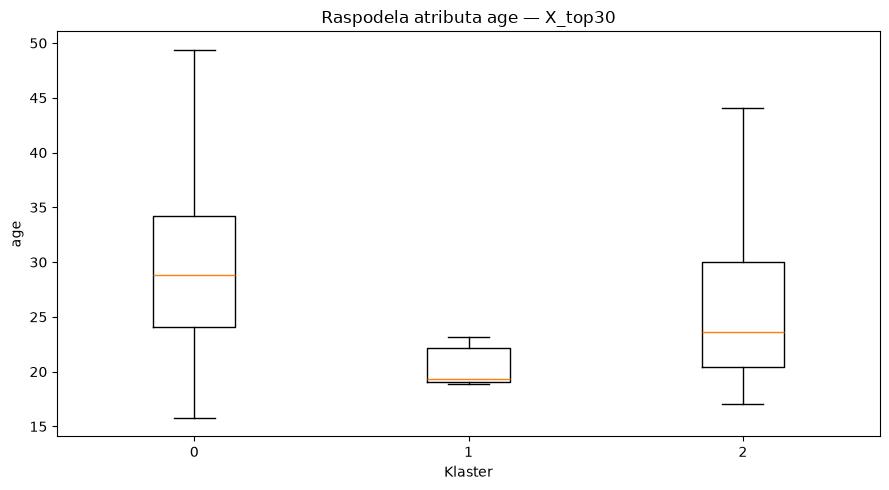

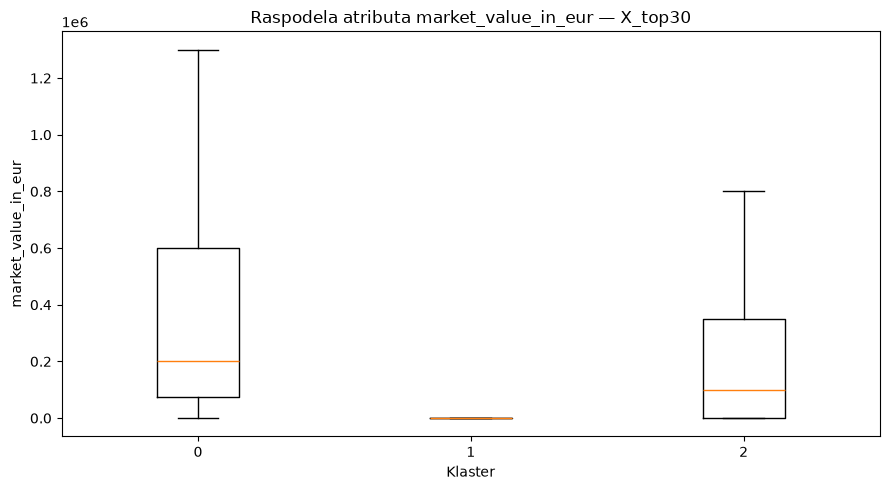

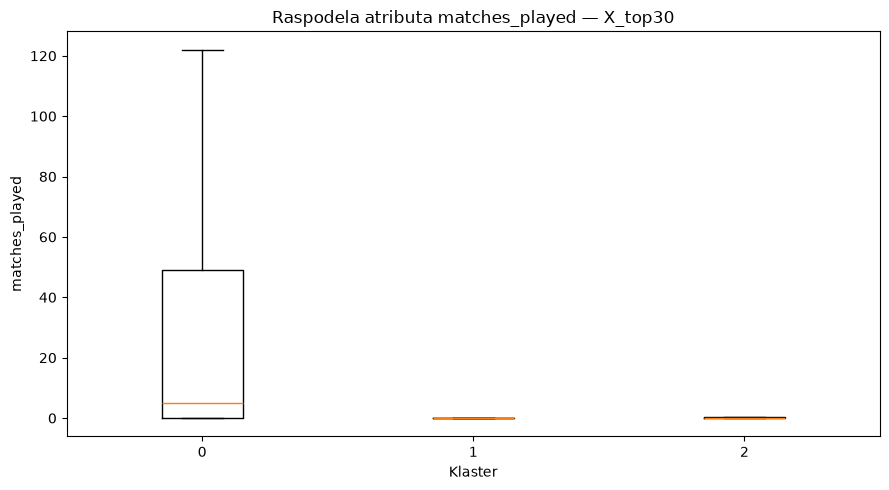

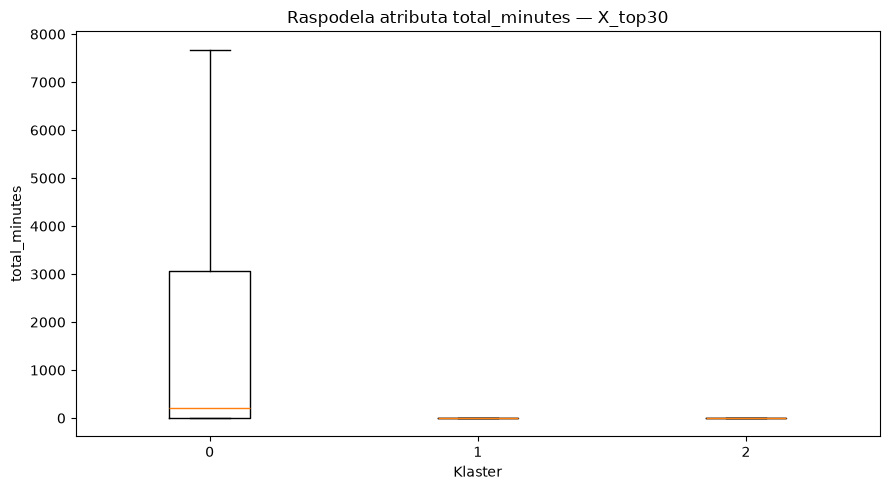

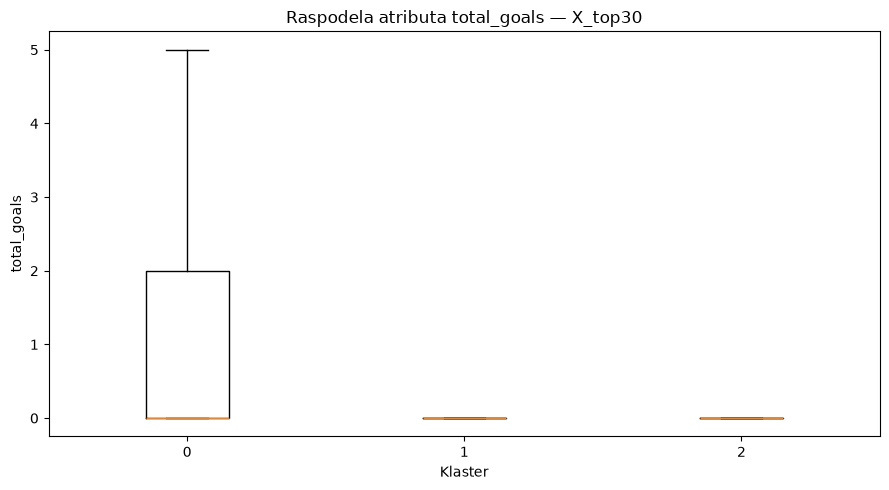

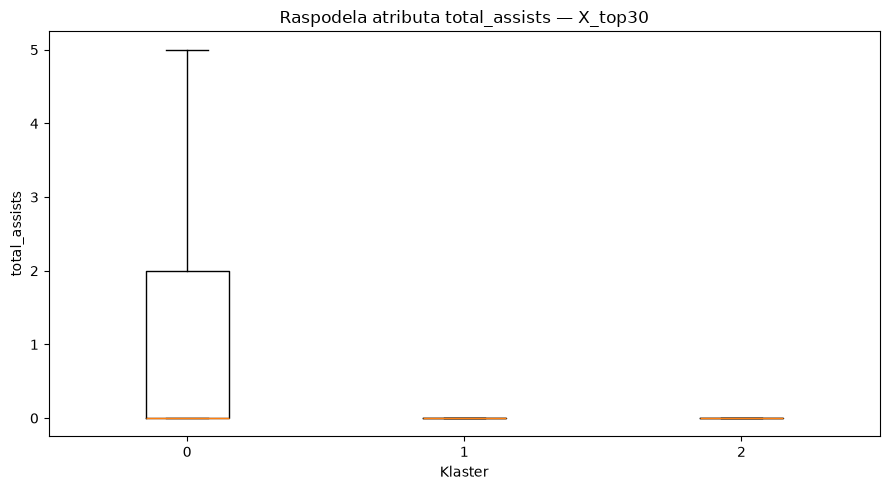


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,9826,98.260,29.616,182.202,3.383,0.381,"1,360,674.740","3,133,491.248",41.780,"2,876.528",14.371,3.911,3.100,31.753,24.111,2.685,13.824,"269,881.437","1,360,674.740","1,090,793.303",Defender,Centre-Back,right,France,Brazil
1,1,10,0.100,20.428,177.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Missing,Unknown,Unknown,"Korea, South","Korea, South"
2,2,164,1.640,25.753,181.470,2.091,0.213,"402,134.146","523,932.927",6.110,399.610,5.417,0.518,0.476,8.750,6.756,0.732,6.317,"57,926.829","402,134.146","344,207.317",Missing,Unknown,right,Norway,Norway


In [23]:
result_X_top30 = run_best_clustering_and_analysis(
    X=X_top30,
    players_df=players_analysis,
    dataset_name="X_top30",
    algorithm="spectral"
)


Pokretanje skupa: X_player_only
Algoritam: spectral
Broj klastera: 3
Dimenzije uzorka: (10000, 177)


/home/janic/projects/ip2-football-players/venv-ip2/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


ANALIZA SKUPA: X_player_only

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,9826,98.260
1,10,0.100
2,164,1.640


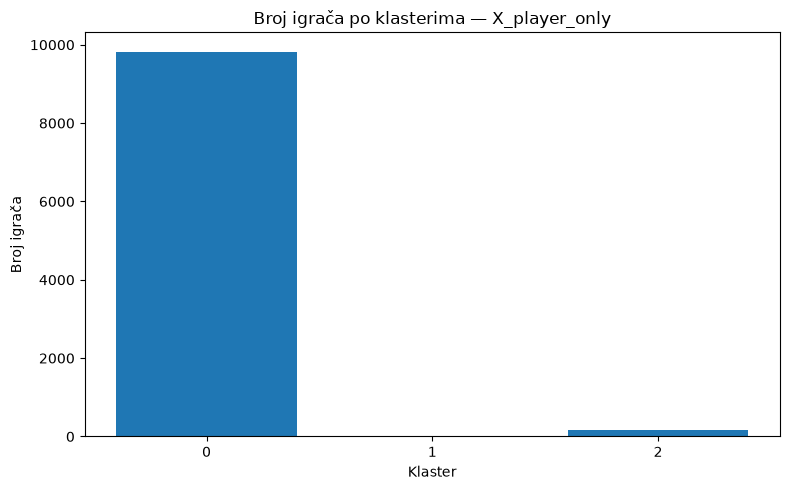


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,29.616,182.202,3.383,0.381,"1,360,674.740","3,133,491.248",41.780,"2,876.528",14.371,3.911,3.100,31.753,24.111,2.685,13.824,"269,881.437","1,360,674.740","1,090,793.303"
1,20.428,177.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,25.753,181.470,2.091,0.213,"402,134.146","523,932.927",6.110,399.610,5.417,0.518,0.476,8.750,6.756,0.732,6.317,"57,926.829","402,134.146","344,207.317"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,28.850,182.000,0.000,0.000,"200,000.000","600,000.000",5.000,207.500,11.582,0.000,0.000,6.000,11.000,0.000,13.000,"75,000.000","200,000.000","100,000.000"
1,19.310,176.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,23.660,182.000,0.000,0.000,"100,000.000","100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,3.000,"50,000.000","100,000.000",0.000



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,9.950,3.790,22.880,63.380
1,100.000,0.000,0.000,0.000
2,41.460,3.050,12.200,43.290



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.100,0.070,0.140,4.050,0.020,0.710,0.840,0.010,0.020,0.120,2.100,0.030,0.020,0.410,5.380,0.160,0.030,0.030,0.360,0.470,0.280,0.100,0.020,0.020,0.220,0.040,1.820,0.050,0.090,0.640,0.960,0.020,0.080,0.360,0.070,1.720,0.010,0.010,0.040,0.270,0.100,4.410,0.010,0.080,0.020,0.040,0.270,5.690,0.030,0.030,0.150,4.330,0.690,2.580,0.060,0.210,0.140,0.010,0.050,0.050,0.220,0.210,0.010,0.090,0.020,0.400,0.230,4.410,0.070,1.740,0.020,1.180,0.030,0.060,1.240,0.010,0.030,0.020,0.070,0.010,0.100,0.010,0.010,0.110,0.010,0.020,0.010,0.150,0.020,0.020,0.010,0.940,0.070,0.020,0.140,0.030,3.440,0.030,0.010,0.100,0.010,0.010,0.950,0.250,0.440,0.010,0.070,0.010,0.250,0.020,0.140,0.010,1.110,2.700,0.010,1.100,2.170,0.030,0.080,0.430,1.810,0.700,0.200,0.420,0.090,0.300,0.340,0.030,0.120,4.800,0.010,0.010,0.010,1.150,0.840,0.010,0.030,0.010,0.130,0.080,0.030,0.100,2.920,0.020,1.250,2.030,0.050,2.460,0.020,1.480,10.120,0.780,0.020,0.250,0.010,0.100,0.910,0.200,0.040,0.060
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,20.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,80.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.610,0.610,0.000,0.000,0.000,0.000,0.000,1.830,0.000,0.000,0.000,0.000,0.000,0.610,0.000,0.000,0.000,2.440,0.000,0.610,0.000,0.000,0.000,0.000,0.000,


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.360,0.320,0.190,0.020,3.930,0.080,0.020,1.080,0.890,0.080,0.020,0.010,0.260,2.850,0.070,0.030,0.630,5.520,0.160,0.130,0.060,0.500,0.350,0.200,0.070,0.010,0.240,0.070,2.110,0.050,0.160,0.100,0.690,1.370,0.020,0.170,0.090,1.130,0.430,2.840,0.030,0.310,0.120,0.010,3.730,0.060,0.010,0.100,0.010,0.060,0.300,4.140,0.020,0.050,0.220,3.410,0.820,3.020,0.030,0.090,0.250,0.150,0.030,0.100,0.060,0.280,0.300,0.030,0.100,0.030,0.650,0.270,4.580,0.130,1.870,0.020,0.030,0.030,1.350,0.280,0.010,0.050,0.010,0.040,0.010,0.010,0.110,0.040,0.070,0.020,0.010,0.420,0.030,0.080,0.030,0.020,0.990,0.090,0.260,0.020,0.620,0.040,3.340,0.010,0.010,0.170,0.040,1.290,0.220,0.240,0.480,0.020,0.020,0.010,0.070,0.010,0.300,0.150,0.030,1.310,2.830,0.030,1.320,3.260,0.050,1.060,2.220,0.920,1.890,0.010,0.090,0.390,0.440,0.020,0.110,0.010,4.710,0.020,0.010,0.180,1.630,0.910,0.010,0.010,0.020,0.010,0.230,0.100,0.070,0.190,3.330,0.010,1.570,0.070,3.590,0.010,1.330,0.690,0.800,0.050,0.250,0.010,0.230,0.060,0.040
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.000,3.660,0.000,0.000,0.000,1.220,0.000,0.000,0.000,0.610,0.000,0.000,0.000,0.000,0.000,0.000,8.540,0.000,0.000,0.000,0.610,0.610,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0

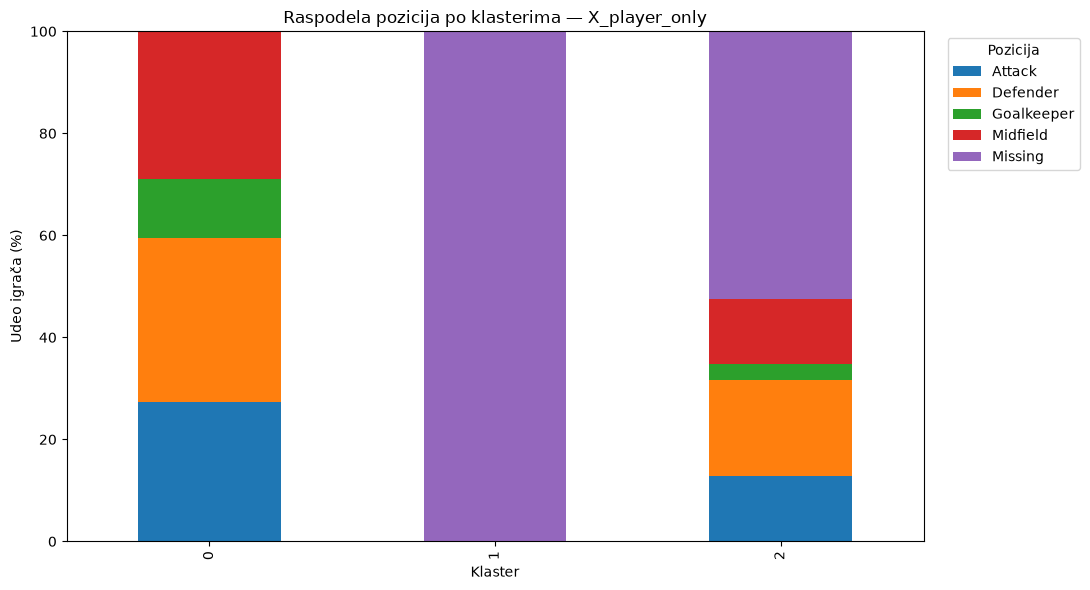

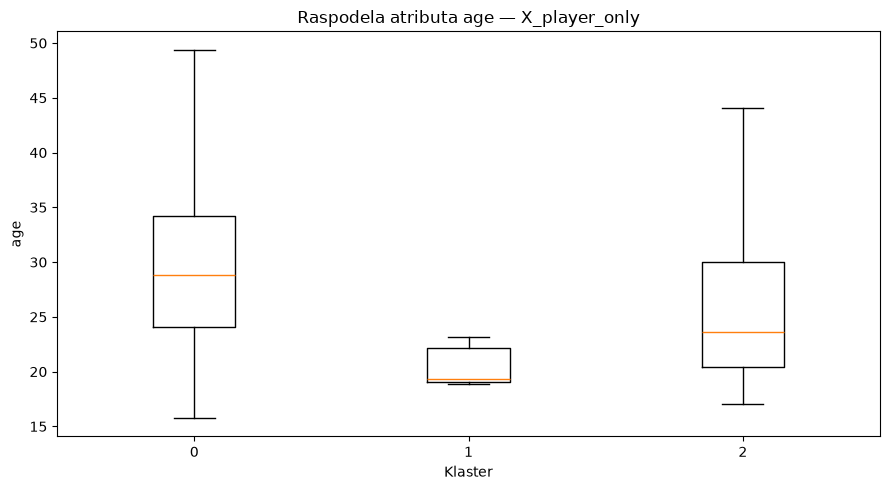

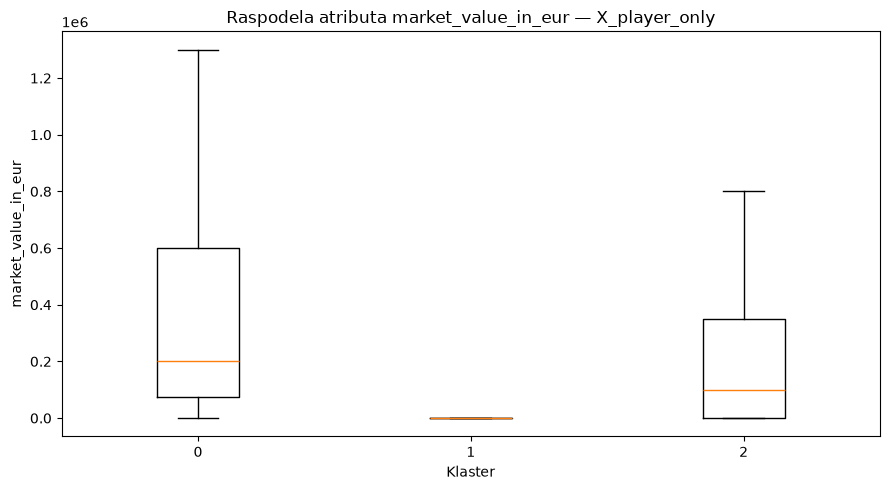

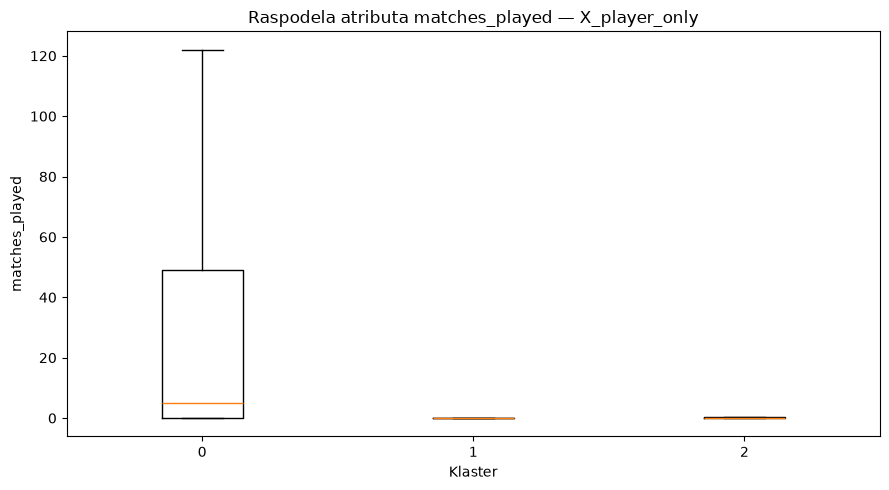

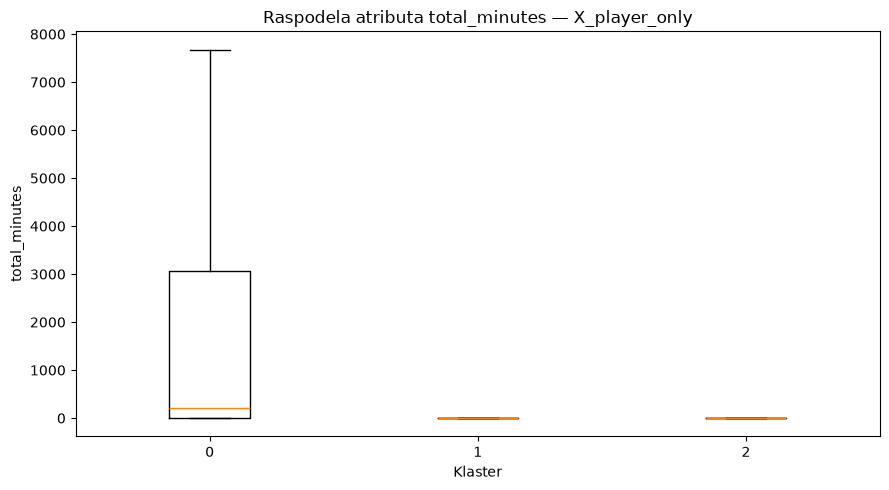

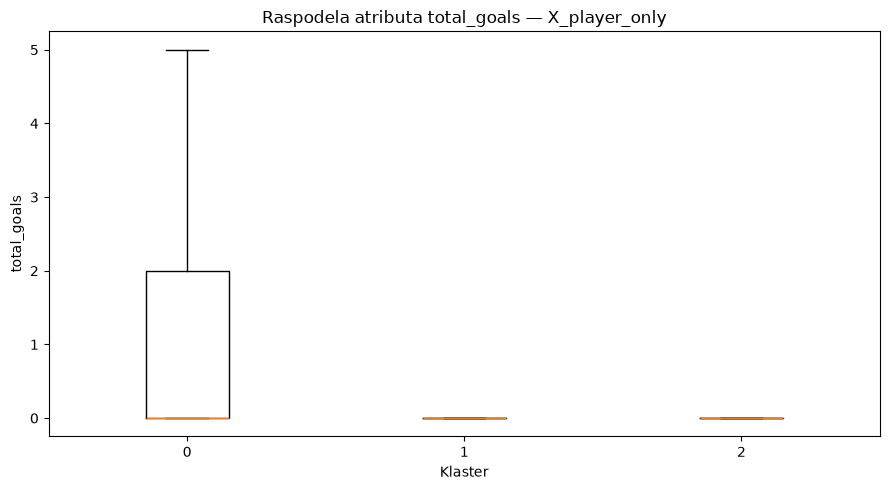

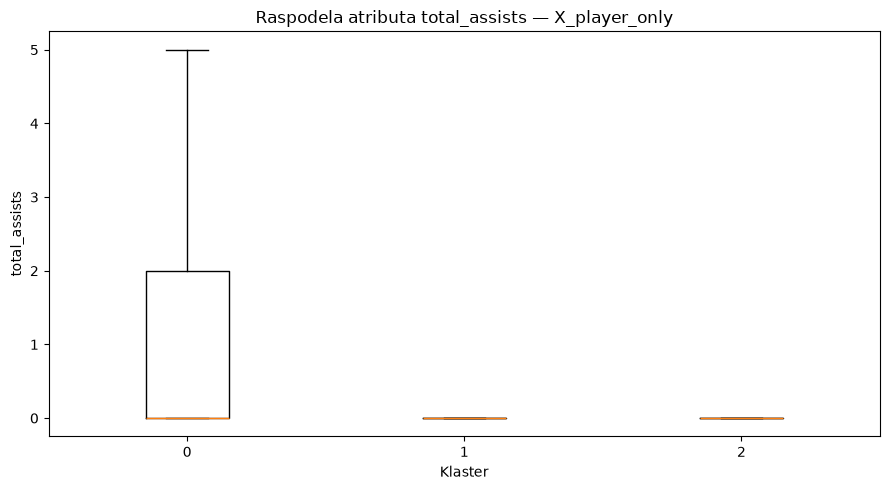


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,9826,98.260,29.616,182.202,3.383,0.381,"1,360,674.740","3,133,491.248",41.780,"2,876.528",14.371,3.911,3.100,31.753,24.111,2.685,13.824,"269,881.437","1,360,674.740","1,090,793.303",Defender,Centre-Back,right,France,Brazil
1,1,10,0.100,20.428,177.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Missing,Unknown,Unknown,"Korea, South","Korea, South"
2,2,164,1.640,25.753,181.470,2.091,0.213,"402,134.146","523,932.927",6.110,399.610,5.417,0.518,0.476,8.750,6.756,0.732,6.317,"57,926.829","402,134.146","344,207.317",Missing,Unknown,right,Norway,Norway


In [24]:
result_X_player_only = run_best_clustering_and_analysis(
    X=X_player_only,
    players_df=players_analysis,
    dataset_name="X_player_only",
    algorithm="spectral"
)


Pokretanje skupa: X_pca90
Algoritam: hierarchical
Broj klastera: 3
Dimenzije uzorka: (10000, 82)
ANALIZA SKUPA: X_pca90

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,207,2.070
1,8824,88.240
2,969,9.690


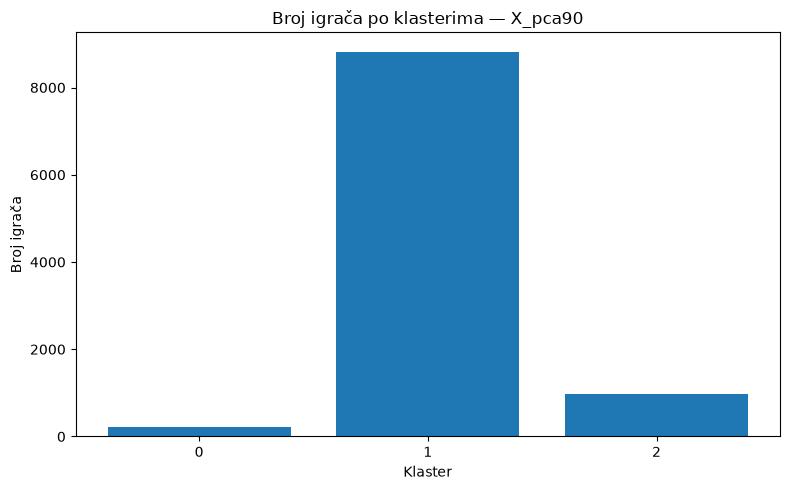


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,26.614,183.473,28.420,6.609,"27,547,584.541","44,347,826.087",193.643,"13,282.986",27.079,41.227,26.923,138.816,67.324,8.280,22.280,"978,623.188","27,547,584.541","26,568,961.353"
1,29.103,182.222,1.934,0.146,"574,199.909","1,292,634.859",22.334,"1,501.433",12.630,1.477,1.183,17.602,17.712,1.105,11.986,"162,154.352","574,199.909","412,045.558"
2,34.176,181.576,10.970,1.157,"2,752,167.183","10,618,575.851",179.946,"12,726.596",25.850,17.486,14.986,133.519,69.961,15.525,27.347,"1,060,815.273","2,752,167.183","1,691,351.909"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,25.470,184.000,12.000,1.000,"22,000,000.000","35,000,000.000",157.000,"10,258.000",28.214,14.000,12.000,109.000,58.000,0.000,21.000,"200,000.000","22,000,000.000","21,900,000.000"
1,28.240,182.000,0.000,0.000,"200,000.000","450,000.000",2.000,69.500,0.000,0.000,0.000,4.000,8.000,0.000,11.000,"50,000.000","200,000.000","50,000.000"
2,34.090,182.000,0.000,0.000,"800,000.000","7,000,000.000",172.000,"11,741.000",27.209,11.000,12.000,123.000,62.000,1.000,28.000,"150,000.000","800,000.000","500,000.000"



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,0.000,4.830,25.600,69.570
1,11.840,3.860,22.140,62.150
2,1.140,2.680,26.930,69.250



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,5.310,0.000,0.000,0.970,0.000,0.000,0.000,4.830,0.000,0.000,0.480,8.210,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.480,0.480,0.000,0.000,0.480,0.000,1.450,0.000,0.000,0.000,0.970,0.970,12.080,0.000,0.000,0.000,0.000,0.000,14.010,0.480,0.000,0.000,6.760,0.000,1.930,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.860,0.000,0.480,0.000,2.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,4.830,0.000,0.000,0.000,0.000,0.000,2.420,0.000,1.450,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,3.380,0.000,0.480,0.000,0.000,0.000,0.000,0.480,0.480,0.480,0.480,0.000,0.000,0.000,0.000,0.480,9.660,0.000,0.000,0.000,1.450,2.420,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.970,0.000,0.480,0.000,0.000,0.970,0.000,0.000,0.000
1,0.090,0.060,0.150,4.080,0.010,0.790,0.830,0.010,0.010,0.140,1.900,0.020,0.020,0.440,5.000,0.170,0.030,0.030,0.360,0.400,0.290,0.080,0.020,0.010,0.190,0.050,1.950,0.050,0.080,0.590,0.920,0.020,0.090,0.360,0.060,1.730,0.010,0.010,0.030,0.230,0.070,4.000,0.010,0.080,0.020,0.050,0.270,4.920,0.000,0.010,0.150,3.970,0.680,2.610,0.060,0.220,0.090,0.010,0.060,0.030,0.220,0.170,0.010,0.070,0.010,0.390,0.250,4.170,0.080,1.890,0.010,1.020,0.030,0.050,1.380,0.010,0.030,0.020,0.080,0.010,0.110,0.010,0.010,0.120,0.010,0.020,0.010,0.120,0.020,0.020,0.000,1.130,0.070,0.010,0.120,0.020,3.180,0.020,0.010,0.100,0.000,0.000,0.950,0.250,1.000,0.010,0.080,0.010,0.230,0.020,0.120,0.010,1.180,2.650,0.010,1.190,2.300,0.030,0.090,0.440,1.810,0.660,0.220,0.450,0.090,0.310,0.370,0.030,0.110,4.340,0.010,0.010,0.010,1.110,0.830,0.010,0.030,0.010,0.150,0.090,0.030,0.110,3.090,0.020,1.300,1.890,0.060,2.640,0.020,1.650,12.010,0.740,0.020,0.200,0.010,0.090,0.900,0.190,0.030,0.030
2,0.210,0.210,0.100,2.790,0.100,0.000,0.830,0.000,0.100,0.000,2.890,0.100,0.000,0.000,7.430,0.100,0.000,0.000,0.310,1.240,0.210,0.310,0.000,0.100,0.410,0.000,0.830,0.100,0.210,1.030,1.340,0.000,0.000,0.210,0.310,1.440,0.000,0.000,0.100,0.520,0.210,5.990,0.000,0.100,0.000,0.000,0.310,10.010,0.210,0.210,0.210,6.710,0.830,2.170,0.100,0.210,0.520,0.000,0.000


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.480,0.000,0.000,0.000,5.310,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,4.350,0.000,0.000,0.970,8.210,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.000,1.450,2.900,0.000,0.000,0.000,0.480,0.970,1.930,0.000,0.970,0.970,0.000,10.140,0.000,0.000,0.000,0.000,0.000,0.000,11.110,0.000,0.000,0.000,5.800,0.000,1.930,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.000,0.000,4.350,0.000,0.480,0.000,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,0.000,0.480,0.000,1.450,0.000,4.830,0.000,0.000,0.000,0.000,2.420,0.000,0.480,1.930,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,3.860,0.000,0.480,0.000,0.000,0.000,0.480,0.970,1.450,0.000,0.000,0.000,0.000,0.000,0.480,0.000,8.700,0.000,0.000,0.000,0.970,2.420,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.480,0.000,0.000,0.000,0.000,0.000,0.970,0.000,0.480,0.000,0.480,0.000,0.000
1,0.360,0.250,0.200,0.030,3.960,0.080,0.020,1.200,0.880,0.090,0.010,0.010,0.270,2.860,0.060,0.030,0.610,5.210,0.170,0.120,0.070,0.410,0.360,0.190,0.080,0.010,0.220,0.080,2.410,0.030,0.140,0.080,0.620,1.300,0.020,0.160,0.100,1.190,0.320,2.950,0.020,0.260,0.090,0.010,3.430,0.060,0.010,0.100,0.010,0.070,0.280,3.760,0.020,0.030,0.220,3.120,0.790,3.120,0.030,0.070,0.230,0.110,0.030,0.110,0.050,0.270,0.260,0.010,0.080,0.030,0.660,0.290,4.310,0.120,2.040,0.010,0.030,0.020,1.600,0.290,0.010,0.060,0.010,0.050,0.020,0.010,0.110,0.050,0.080,0.020,0.010,0.350,0.030,0.090,0.030,0.010,1.190,0.090,0.260,0.020,0.510,0.030,3.230,0.010,0.000,0.190,0.030,1.330,0.220,0.220,1.330,0.020,0.020,0.010,0.080,0.010,0.270,0.120,0.030,1.420,2.720,0.030,1.440,3.400,0.060,1.170,2.280,0.830,1.920,0.010,0.090,0.410,0.450,0.020,0.100,0.010,4.300,0.020,0.010,0.120,1.690,0.880,0.010,0.010,0.020,0.010,0.260,0.110,0.080,0.230,3.490,0.010,1.630,0.080,3.730,0.010,1.470,0.690,0.760,0.050,0.220,0.010,0.200,0.060,0.010
2,0.210,0.930,0.100,0.000,2.680,0.100,0.000,0.100,0.830,0.000,0.100,0.000,0.210,2.580,0.210,0.000,0.620,6.910,0.100,0.210,0.000,1.340,0.210,0.310,0.000,0.000,0.410,0.000,0.830,0.210,0.410,0.310,1.140,1.550,0.000,0.310,0.000,0.520,1.240,1.550,0.100,0.520,0.210,0.0

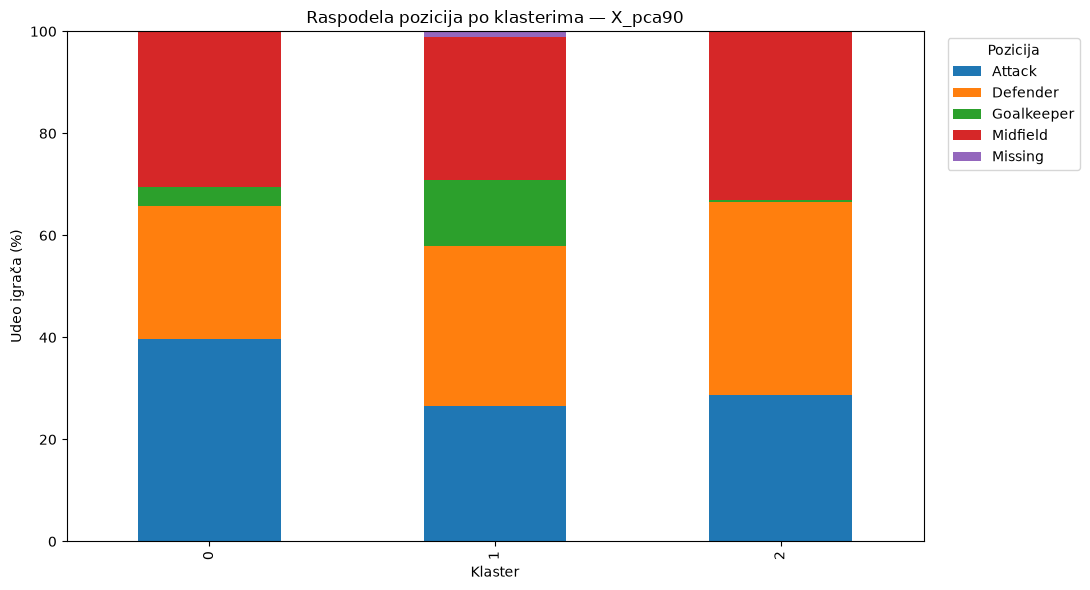

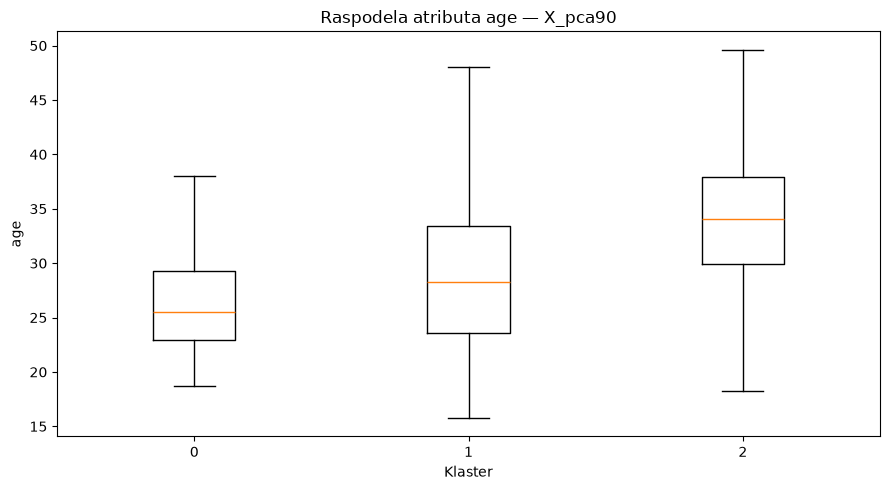

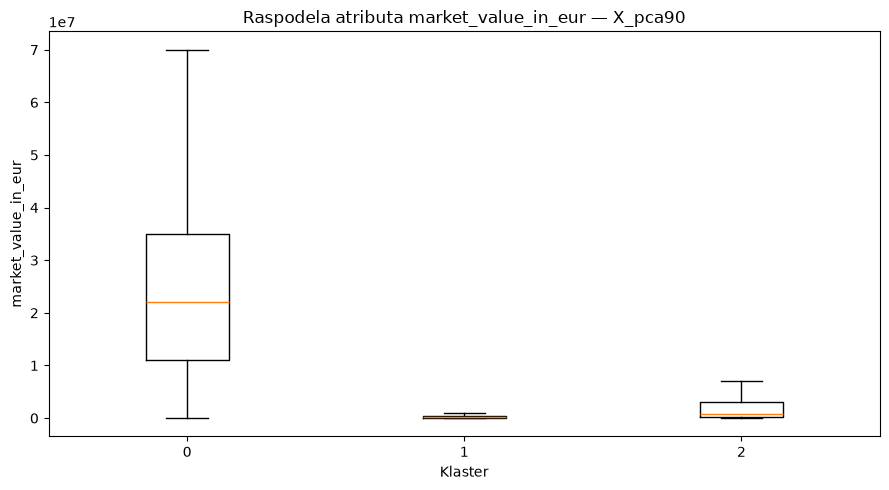

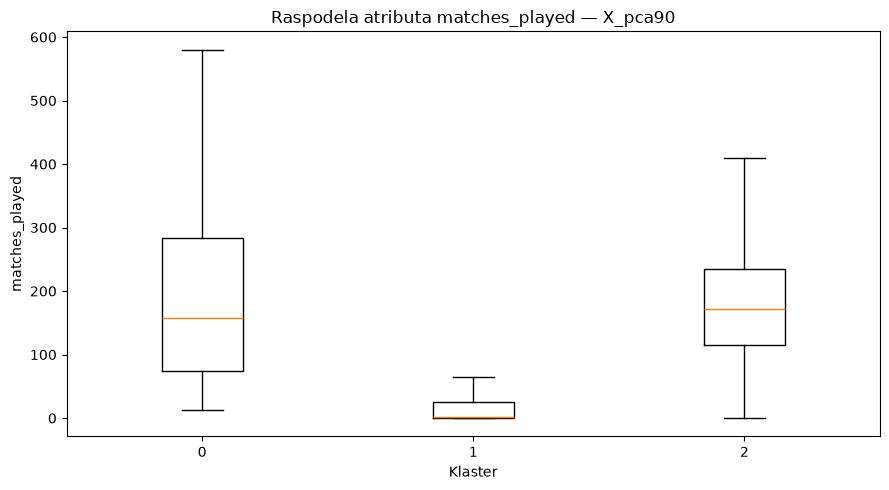

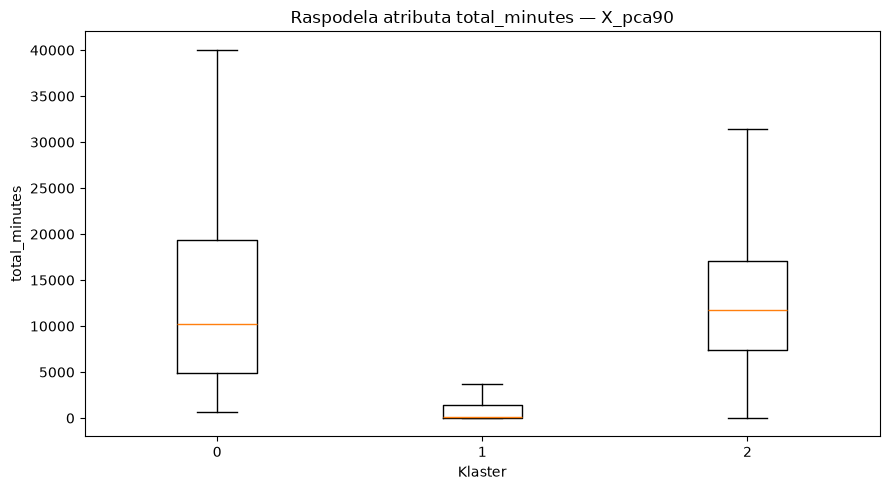

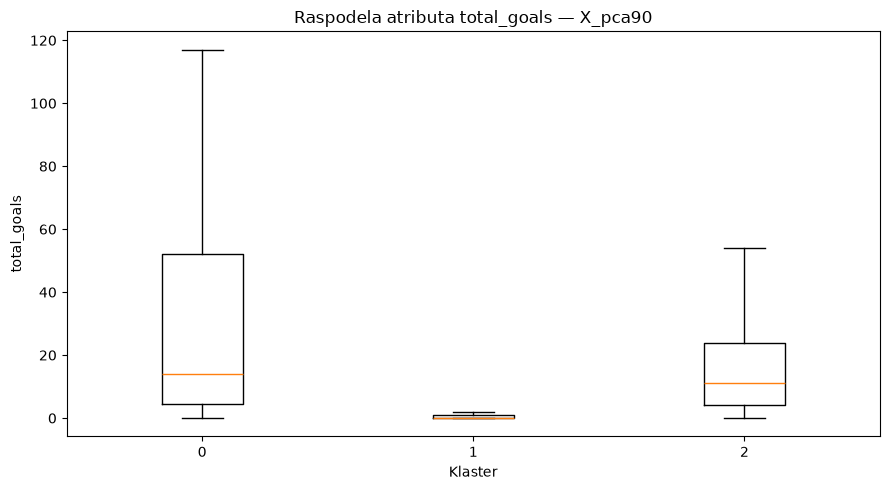

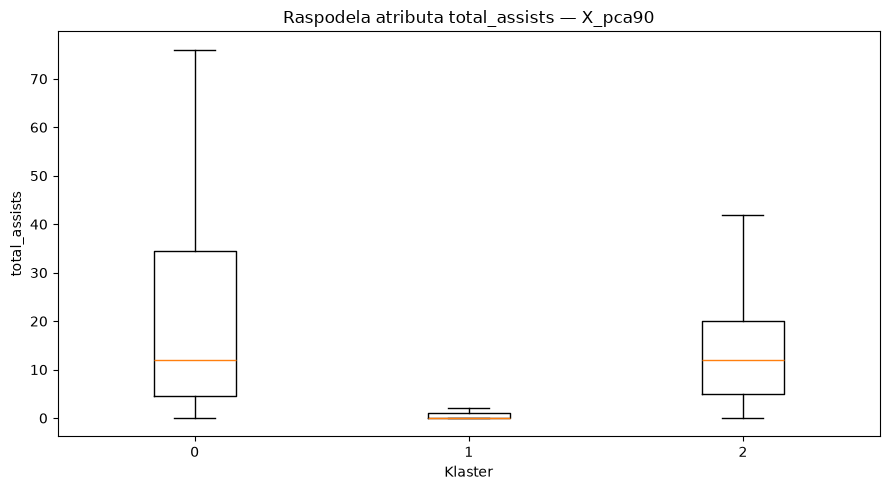


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,207,2.070,26.614,183.473,28.420,6.609,"27,547,584.541","44,347,826.087",193.643,"13,282.986",27.079,41.227,26.923,138.816,67.324,8.280,22.280,"978,623.188","27,547,584.541","26,568,961.353",Attack,Centre-Forward,right,France,France
1,1,8824,88.240,29.103,182.222,1.934,0.146,"574,199.909","1,292,634.859",22.334,"1,501.433",12.630,1.477,1.183,17.602,17.712,1.105,11.986,"162,154.352","574,199.909","412,045.558",Defender,Centre-Back,right,Brazil,Brazil
2,2,969,9.690,34.176,181.576,10.970,1.157,"2,752,167.183","10,618,575.851",179.946,"12,726.596",25.850,17.486,14.986,133.519,69.961,15.525,27.347,"1,060,815.273","2,752,167.183","1,691,351.909",Defender,Centre-Back,right,France,Brazil


In [25]:
result_X_pca90 = run_best_clustering_and_analysis(
    X=X_pca90,
    players_df=players_analysis,
    dataset_name="X_pca90",
    algorithm="hierarchical"
)


Pokretanje skupa: X_no_countries
Algoritam: hierarchical
Broj klastera: 3
Dimenzije uzorka: (10000, 152)
ANALIZA SKUPA: X_no_countries

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,1206,12.060
1,8777,87.770
2,17,0.170


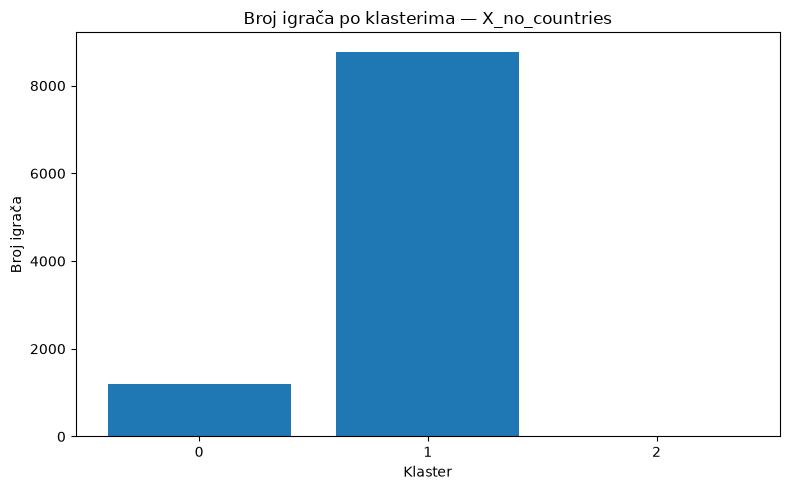


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,32.964,181.815,10.839,1.412,"5,813,917.910","13,586,546.434",159.998,"10,897.818",26.115,19.502,13.915,113.775,64.622,12.966,25.227,"982,848.259","5,813,917.910","4,831,069.652"
1,29.073,182.236,2.163,0.156,"610,226.159","1,401,986.442",24.163,"1,675.633",12.553,1.379,1.394,19.494,18.073,1.188,12.063,"160,440.925","610,226.159","449,785.234"
2,29.799,182.059,89.941,41.882,"62,847,058.824","128,529,411.765",382.118,"28,264.588",25.063,170.059,89.588,301.588,85.882,26.059,33.706,"3,991,176.471","62,847,058.824","58,855,882.353"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,33.065,182.000,0.000,0.000,"900,000.000","7,500,000.000",148.000,"9,634.000",28.209,12.000,9.000,99.000,55.000,0.000,26.000,"150,000.000","900,000.000","600,000.000"
1,28.230,182.000,0.000,0.000,"200,000.000","450,000.000",2.000,71.000,0.000,0.000,0.000,4.000,8.000,0.000,11.000,"50,000.000","200,000.000","50,000.000"
2,27.000,181.000,57.000,21.000,"30,000,000.000","120,000,000.000",361.000,"26,915.000",26.035,115.000,72.000,294.000,92.000,4.000,31.000,"400,000.000","30,000,000.000","29,975,000.000"



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,1.240,3.900,22.470,72.390
1,11.860,3.760,22.660,61.720
2,0.000,0.000,47.060,52.940



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.170,0.080,4.060,0.080,0.170,1.000,0.000,0.000,0.000,2.900,0.080,0.000,0.170,5.890,0.080,0.000,0.000,0.410,0.910,0.250,0.170,0.000,0.080,0.410,0.000,0.660,0.080,0.170,1.330,0.830,0.080,0.080,0.250,0.080,2.240,0.000,0.000,0.000,0.330,0.250,7.050,0.000,0.080,0.000,0.080,0.250,10.700,0.250,0.170,0.330,5.560,0.580,2.490,0.170,0.170,0.580,0.000,0.000,0.080,0.000,0.580,0.000,0.170,0.000,0.330,0.170,5.220,0.000,0.830,0.080,2.160,0.000,0.080,0.330,0.000,0.000,0.000,0.000,0.000,0.080,0.000,0.000,0.000,0.000,0.000,0.000,0.170,0.000,0.000,0.000,0.170,0.080,0.080,0.080,0.170,4.310,0.080,0.000,0.000,0.080,0.080,1.160,0.250,0.750,0.000,0.000,0.000,0.500,0.000,0.250,0.000,0.580,2.990,0.000,0.250,1.740,0.000,0.170,0.250,2.400,1.160,0.000,0.080,0.080,0.170,0.080,0.000,0.330,8.210,0.000,0.000,0.000,1.240,0.830,0.000,0.000,0.000,0.000,0.000,0.000,0.170,0.830,0.000,0.830,2.160,0.000,0.580,0.000,0.410,1.330,1.080,0.000,0.410,0.000,0.170,0.750,0.410,0.080,0.170
1,0.110,0.060,0.150,3.960,0.010,0.770,0.810,0.010,0.020,0.140,1.930,0.020,0.020,0.430,5.210,0.170,0.030,0.030,0.340,0.410,0.280,0.090,0.020,0.010,0.180,0.050,1.960,0.050,0.080,0.540,0.970,0.010,0.080,0.360,0.080,1.630,0.010,0.010,0.050,0.260,0.070,3.960,0.010,0.080,0.020,0.030,0.270,4.910,0.000,0.010,0.130,4.110,0.690,2.560,0.050,0.220,0.080,0.010,0.060,0.050,0.250,0.160,0.010,0.080,0.020,0.410,0.240,4.230,0.080,1.880,0.010,1.030,0.030,0.060,1.380,0.010,0.030,0.020,0.080,0.010,0.100,0.010,0.010,0.130,0.010,0.020,0.010,0.150,0.020,0.020,0.010,1.140,0.070,0.010,0.150,0.010,3.240,0.020,0.010,0.110,0.000,0.000,0.900,0.250,0.990,0.010,0.080,0.010,0.220,0.020,0.130,0.010,1.160,2.590,0.010,1.200,2.190,0.030,0.070,0.440,1.730,0.630,0.230,0.460,0.090,0.310,0.360,0.030,0.090,4.250,0.010,0.010,0.010,1.120,0.830,0.010,0.030,0.010,0.150,0.090,0.030,0.100,3.160,0.020,1.290,1.980,0.060,2.710,0.020,1.630,12.000,0.730,0.020,0.230,0.010,0.090,0.900,0.170,0.030,0.050
2,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,11.760,0.000,0.000,0.000,11.760,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.880,17.650,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,0.00


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.170,1.000,0.000,0.000,3.650,0.080,0.000,0.170,0.910,0.000,0.000,0.000,0.080,2.820,0.170,0.000,0.330,5.640,0.080,0.170,0.000,1.160,0.330,0.170,0.000,0.000,0.410,0.000,0.750,0.080,0.250,0.250,1.490,1.410,0.000,0.250,0.000,0.580,1.160,2.400,0.080,0.330,0.250,0.000,5.390,0.080,0.000,0.080,0.000,0.080,0.250,7.050,0.000,0.170,0.500,4.390,0.910,2.740,0.000,0.250,0.330,0.500,0.000,0.000,0.080,0.080,0.580,0.170,0.170,0.000,0.410,0.080,5.640,0.170,0.830,0.080,0.000,0.000,0.330,0.250,0.000,0.000,0.000,0.000,0.000,0.000,0.170,0.000,0.000,0.000,0.000,0.580,0.080,0.000,0.000,0.080,0.170,0.080,0.250,0.000,0.910,0.170,3.320,0.000,0.080,0.080,0.080,1.240,0.410,0.410,0.750,0.000,0.000,0.000,0.000,0.000,0.580,0.330,0.000,0.580,3.320,0.000,0.250,2.650,0.000,0.410,2.650,1.580,1.160,0.000,0.080,0.170,0.330,0.000,0.330,0.000,7.960,0.080,0.000,0.500,1.580,1.080,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.170,1.160,0.000,1.410,0.000,1.580,0.000,0.500,0.410,1.080,0.000,0.330,0.000,0.410,0.080,0.170
1,0.380,0.220,0.220,0.030,3.890,0.080,0.020,1.200,0.870,0.090,0.020,0.010,0.280,2.850,0.060,0.030,0.660,5.400,0.170,0.130,0.070,0.410,0.340,0.210,0.080,0.010,0.210,0.080,2.420,0.050,0.150,0.080,0.580,1.360,0.020,0.160,0.100,1.180,0.320,2.850,0.020,0.300,0.090,0.010,3.440,0.060,0.010,0.100,0.010,0.060,0.300,3.680,0.020,0.030,0.180,3.210,0.800,3.080,0.030,0.070,0.240,0.100,0.030,0.110,0.060,0.310,0.250,0.010,0.090,0.030,0.680,0.300,4.360,0.130,2.030,0.010,0.030,0.030,1.600,0.300,0.010,0.060,0.010,0.050,0.020,0.010,0.100,0.050,0.080,0.020,0.010,0.390,0.020,0.090,0.030,0.010,1.200,0.090,0.260,0.020,0.580,0.020,3.260,0.010,0.000,0.180,0.030,1.280,0.190,0.220,1.320,0.020,0.020,0.010,0.080,0.010,0.250,0.130,0.030,1.390,2.690,0.030,1.450,3.290,0.060,1.150,2.180,0.810,1.950,0.010,0.090,0.410,0.440,0.020,0.080,0.010,4.180,0.010,0.010,0.140,1.670,0.870,0.010,0.010,0.020,0.010,0.260,0.110,0.080,0.220,3.580,0.010,1.570,0.080,3.870,0.010,1.460,0.720,0.750,0.060,0.240,0.010,0.210,0.060,0.020
2,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,11.760,0.000,0.000,0.000,11.760,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.880,0.0

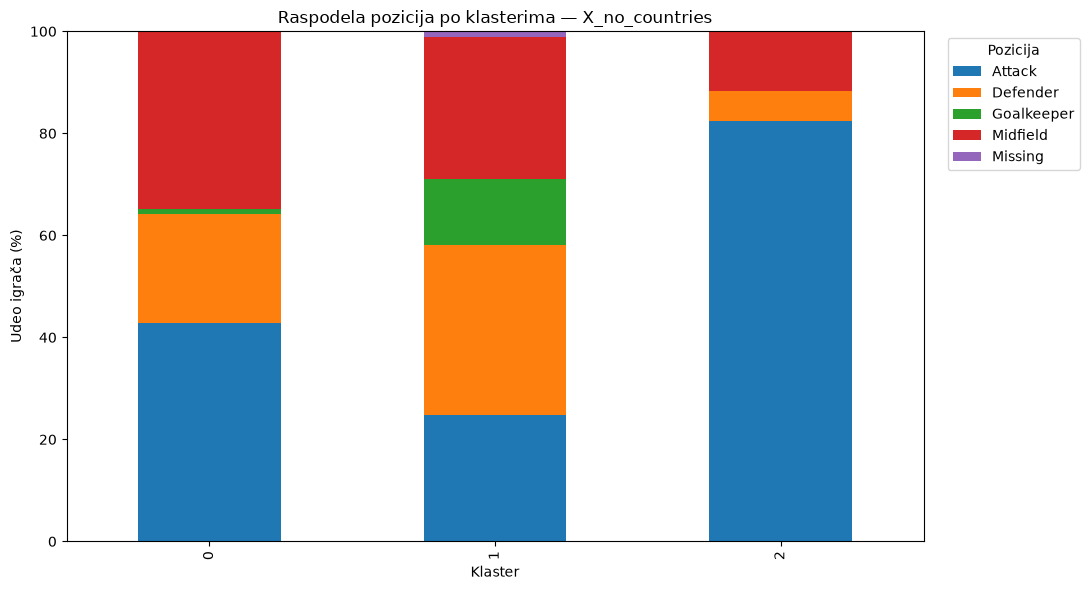

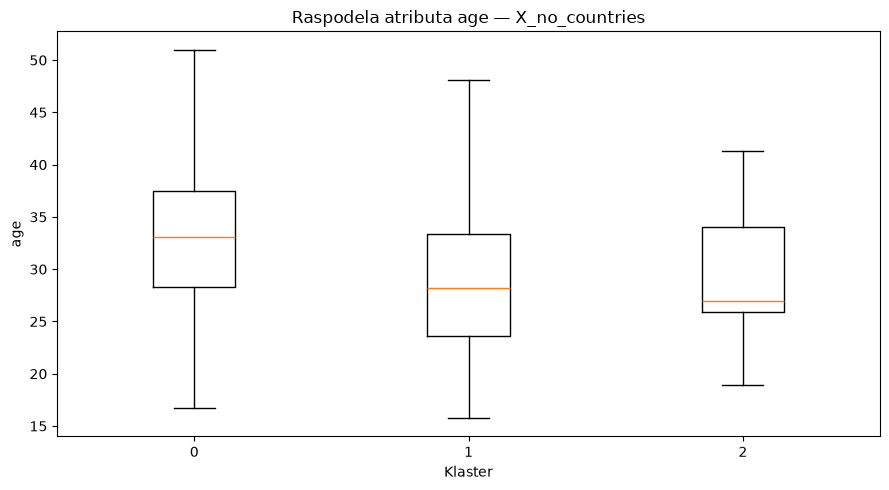

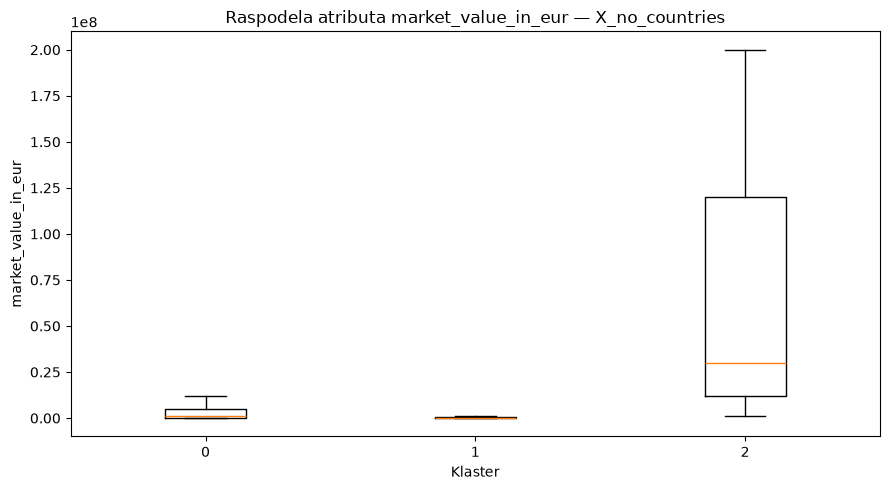

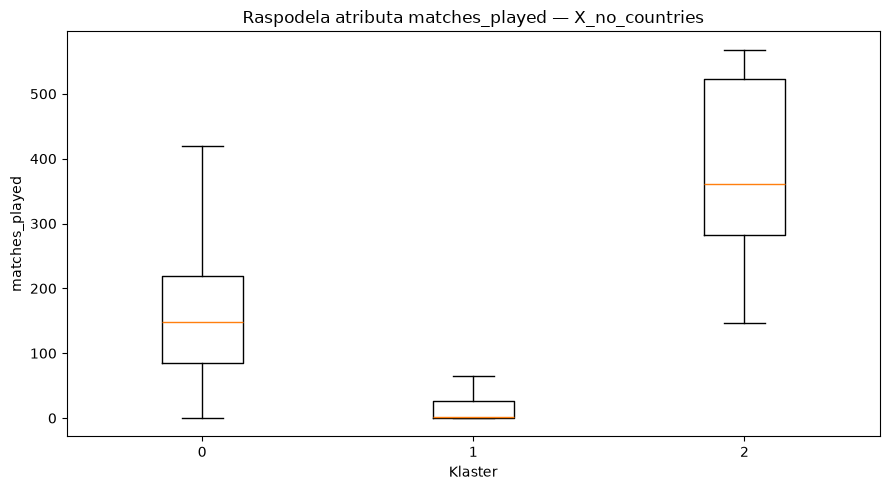

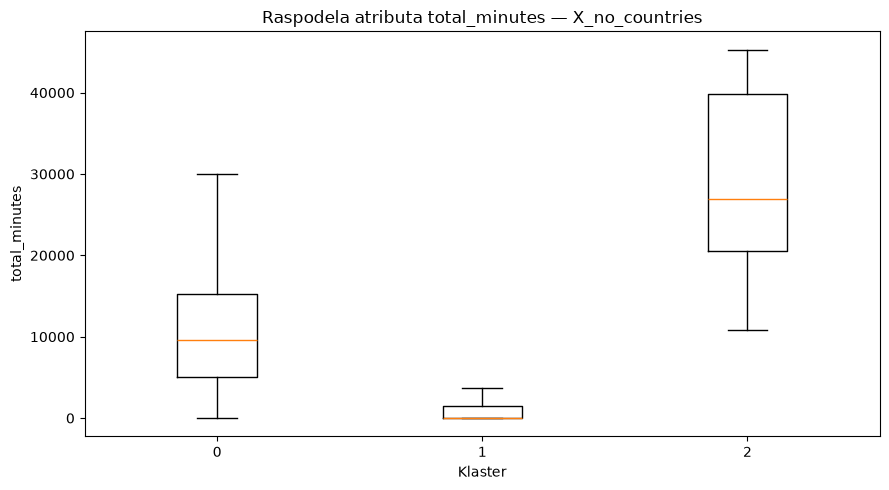

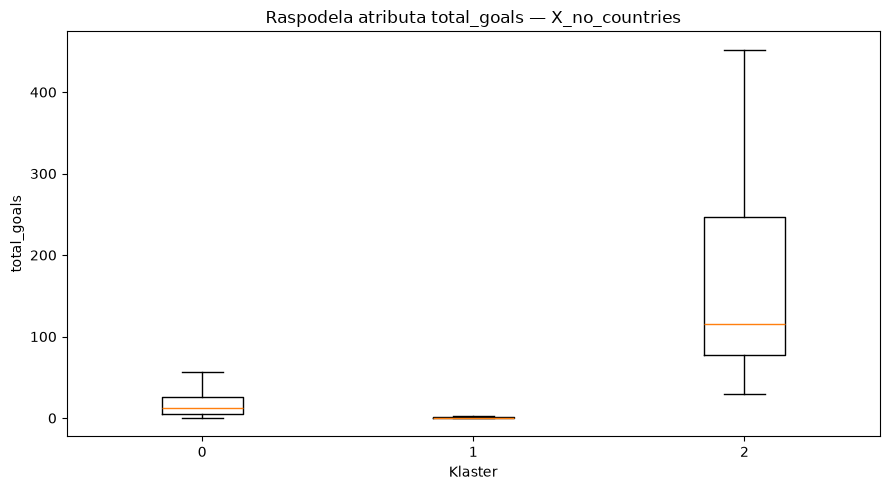

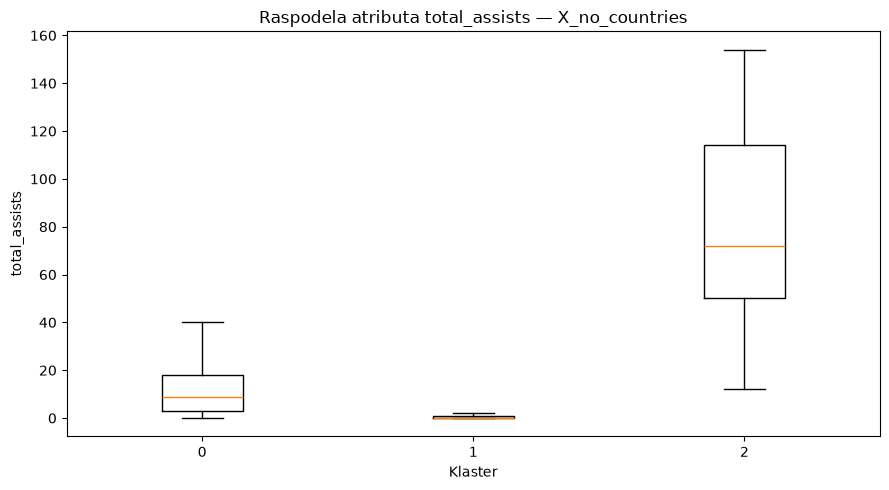


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,1206,12.060,32.964,181.815,10.839,1.412,"5,813,917.910","13,586,546.434",159.998,"10,897.818",26.115,19.502,13.915,113.775,64.622,12.966,25.227,"982,848.259","5,813,917.910","4,831,069.652",Attack,Centre-Forward,right,France,Spain
1,1,8777,87.770,29.073,182.236,2.163,0.156,"610,226.159","1,401,986.442",24.163,"1,675.633",12.553,1.379,1.394,19.494,18.073,1.188,12.063,"160,440.925","610,226.159","449,785.234",Defender,Centre-Back,right,Brazil,Brazil
2,2,17,0.170,29.799,182.059,89.941,41.882,"62,847,058.824","128,529,411.765",382.118,"28,264.588",25.063,170.059,89.588,301.588,85.882,26.059,33.706,"3,991,176.471","62,847,058.824","58,855,882.353",Attack,Centre-Forward,right,England,Belgium


In [26]:
result_X_no_countries = run_best_clustering_and_analysis(
    X=X_no_countries,
    players_df=players_analysis,
    dataset_name="X_no_countries",
    algorithm="hierarchical"
)


Pokretanje skupa: X_no_countries_no_club
Algoritam: hierarchical
Broj klastera: 3
Dimenzije uzorka: (10000, 114)
ANALIZA SKUPA: X_no_countries_no_club

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,1551,15.510
1,8439,84.390
2,10,0.100


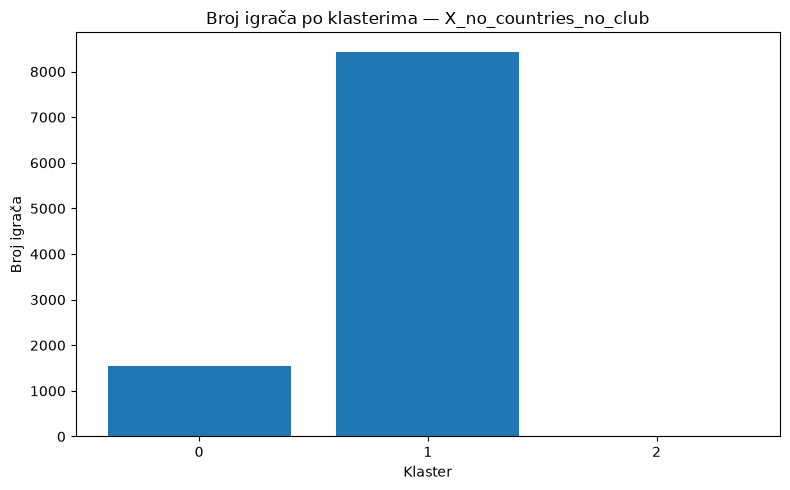


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,32.268,181.443,11.317,1.373,"4,826,489.362","11,966,199.226",153.638,"10,450.804",26.469,17.344,13.607,110.596,65.905,9.640,25.044,"803,671.825","4,826,489.362","4,022,817.537"
1,29.042,182.321,1.782,0.132,"599,722.123","1,266,267.923",20.060,"1,399.293",11.948,1.122,0.984,16.419,16.023,1.330,11.576,"159,809.812","599,722.123","439,912.312"
2,30.080,182.000,98.800,53.700,"88,900,000.000","163,000,000.000",395.000,"31,246.700",22.083,214.700,112.400,333.800,58.700,33.200,34.100,"6,622,500.000","88,900,000.000","82,277,500.000"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,32.180,182.000,1.000,0.000,"800,000.000","6,000,000.000",141.000,"8,946.000",28.643,9.000,9.000,94.000,58.000,0.000,26.000,"150,000.000","800,000.000","600,000.000"
1,28.090,182.000,0.000,0.000,"200,000.000","400,000.000",1.000,43.000,0.000,0.000,0.000,4.000,7.000,0.000,10.000,"50,000.000","200,000.000","50,000.000"
2,29.500,180.500,80.500,45.500,"75,000,000.000","165,000,000.000",398.500,"31,753.500",23.180,189.500,92.500,349.500,46.500,6.000,34.500,"2,750,000.000","75,000,000.000","71,487,500.000"



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,1.030,3.870,26.820,68.280
1,12.320,3.760,21.870,62.050
2,0.000,0.000,60.000,40.000



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.060,0.130,0.130,3.350,0.060,0.320,1.230,0.000,0.060,0.000,3.350,0.060,0.000,0.190,6.450,0.130,0.000,0.000,0.450,0.840,0.190,0.130,0.000,0.000,0.580,0.000,0.390,0.060,0.130,1.030,1.230,0.060,0.060,0.320,0.130,2.450,0.060,0.000,0.060,0.520,0.190,6.510,0.000,0.130,0.000,0.060,0.190,9.220,0.130,0.130,0.260,5.540,0.900,2.190,0.060,0.190,0.450,0.000,0.000,0.190,0.060,0.640,0.000,0.260,0.000,0.320,0.190,4.580,0.060,0.770,0.000,1.610,0.000,0.060,0.390,0.000,0.060,0.060,0.060,0.000,0.000,0.060,0.000,0.000,0.000,0.000,0.000,0.260,0.000,0.000,0.060,0.320,0.060,0.060,0.190,0.000,4.580,0.060,0.000,0.060,0.000,0.000,1.030,0.260,1.290,0.000,0.130,0.000,0.580,0.000,0.190,0.000,0.520,3.480,0.000,0.520,2.000,0.000,0.190,0.190,2.450,0.710,0.060,0.060,0.000,0.190,0.130,0.000,0.260,7.800,0.000,0.000,0.000,1.230,0.770,0.000,0.000,0.000,0.060,0.000,0.000,0.130,0.640,0.000,0.970,1.740,0.060,1.480,0.000,0.320,1.870,0.970,0.060,0.450,0.000,0.060,0.970,0.390,0.060,0.190
1,0.110,0.060,0.140,4.090,0.010,0.770,0.760,0.010,0.010,0.140,1.800,0.020,0.020,0.440,5.080,0.170,0.040,0.040,0.330,0.400,0.300,0.090,0.020,0.020,0.150,0.050,2.060,0.050,0.080,0.560,0.900,0.010,0.080,0.360,0.070,1.560,0.000,0.010,0.040,0.230,0.070,3.930,0.010,0.070,0.020,0.040,0.280,4.940,0.010,0.010,0.130,4.060,0.640,2.620,0.060,0.210,0.080,0.010,0.060,0.020,0.250,0.130,0.010,0.060,0.020,0.410,0.240,4.300,0.070,1.930,0.020,1.080,0.040,0.060,1.410,0.010,0.020,0.010,0.070,0.010,0.120,0.000,0.010,0.130,0.010,0.020,0.010,0.130,0.020,0.020,0.000,1.150,0.070,0.010,0.130,0.040,3.160,0.020,0.010,0.110,0.010,0.010,0.910,0.250,0.900,0.010,0.060,0.010,0.190,0.020,0.130,0.010,1.200,2.490,0.010,1.180,2.160,0.040,0.060,0.460,1.690,0.690,0.230,0.470,0.110,0.310,0.370,0.040,0.090,4.160,0.010,0.010,0.010,1.110,0.840,0.010,0.040,0.010,0.140,0.090,0.040,0.110,3.280,0.020,1.280,2.050,0.050,2.630,0.020,1.690,12.320,0.730,0.010,0.210,0.010,0.110,0.880,0.170,0.040,0.040
2,0.000,0.000,0.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,20.000,0.000,0.000,0.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,10.000,30.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.320,0.710,0.190,0.000,3.090,0.060,0.000,0.390,1.030,0.000,0.060,0.000,0.130,2.970,0.060,0.000,0.710,6.060,0.130,0.130,0.000,0.900,0.320,0.190,0.000,0.000,0.580,0.000,0.520,0.130,0.190,0.130,1.160,1.740,0.000,0.190,0.000,0.840,1.100,2.770,0.060,0.520,0.190,0.000,4.900,0.130,0.000,0.130,0.000,0.060,0.260,6.060,0.000,0.130,0.190,4.190,1.030,2.320,0.060,0.190,0.390,0.390,0.000,0.060,0.190,0.130,0.640,0.130,0.320,0.000,0.580,0.190,5.030,0.190,0.770,0.000,0.000,0.000,0.390,0.390,0.000,0.060,0.000,0.000,0.000,0.000,0.000,0.060,0.060,0.000,0.000,0.640,0.060,0.060,0.000,0.060,0.390,0.060,0.190,0.000,1.100,0.000,3.740,0.000,0.060,0.060,0.060,1.230,0.190,0.320,1.290,0.000,0.000,0.000,0.130,0.000,0.580,0.260,0.000,0.520,3.680,0.000,0.520,2.900,0.000,0.190,2.580,1.030,1.350,0.000,0.060,0.260,0.260,0.000,0.260,0.000,7.480,0.060,0.000,0.450,1.420,0.840,0.000,0.000,0.000,0.000,0.060,0.000,0.060,0.190,0.900,0.000,1.610,0.060,2.320,0.000,0.450,0.580,0.970,0.190,0.390,0.000,0.320,0.060,0.190
1,0.360,0.240,0.190,0.040,3.990,0.080,0.020,1.200,0.840,0.090,0.010,0.010,0.280,2.820,0.070,0.040,0.600,5.320,0.170,0.130,0.070,0.430,0.340,0.200,0.080,0.010,0.180,0.080,2.520,0.040,0.150,0.090,0.600,1.290,0.020,0.170,0.110,1.160,0.300,2.800,0.020,0.260,0.090,0.010,3.450,0.050,0.010,0.090,0.010,0.060,0.300,3.720,0.020,0.040,0.230,3.210,0.770,3.160,0.020,0.070,0.230,0.110,0.040,0.110,0.040,0.310,0.230,0.010,0.060,0.040,0.660,0.280,4.420,0.120,2.090,0.020,0.040,0.040,1.640,0.270,0.010,0.050,0.010,0.050,0.020,0.010,0.130,0.040,0.070,0.020,0.010,0.370,0.020,0.080,0.040,0.010,1.200,0.090,0.270,0.020,0.530,0.050,3.200,0.010,0.000,0.190,0.040,1.280,0.230,0.230,1.240,0.020,0.020,0.010,0.060,0.010,0.240,0.130,0.040,1.430,2.610,0.040,1.450,3.270,0.060,1.220,2.170,0.880,1.960,0.010,0.090,0.400,0.460,0.020,0.080,0.010,4.110,0.010,0.010,0.130,1.710,0.900,0.010,0.010,0.020,0.010,0.260,0.120,0.070,0.210,3.720,0.010,1.540,0.070,3.830,0.010,1.500,0.700,0.760,0.020,0.230,0.010,0.210,0.060,0.010
2,0.000,0.000,0.000,0.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,20.000,0.000,0.000,0.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,10.000,0

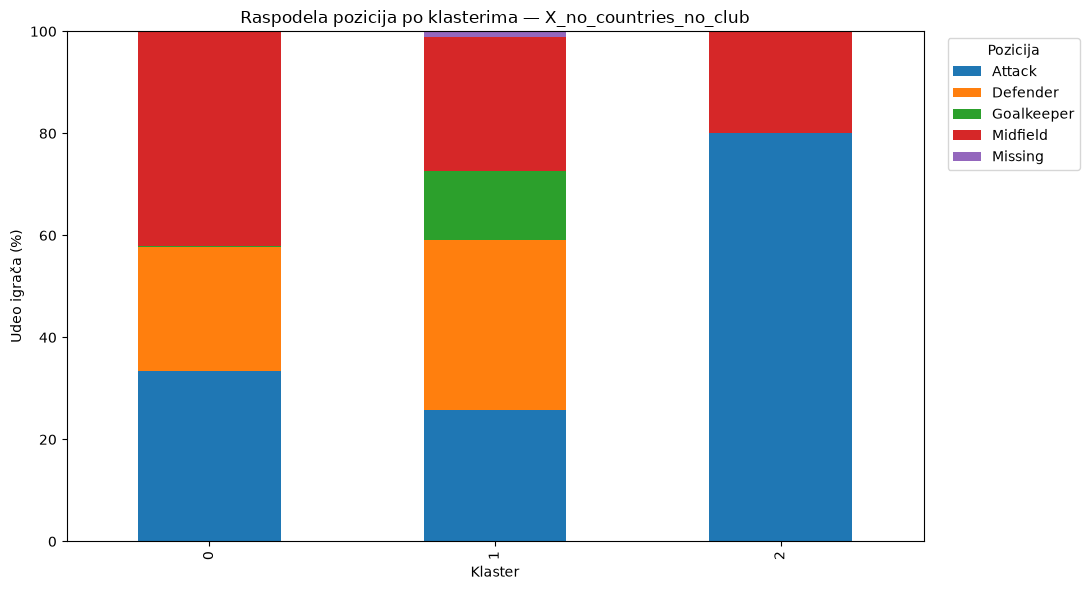

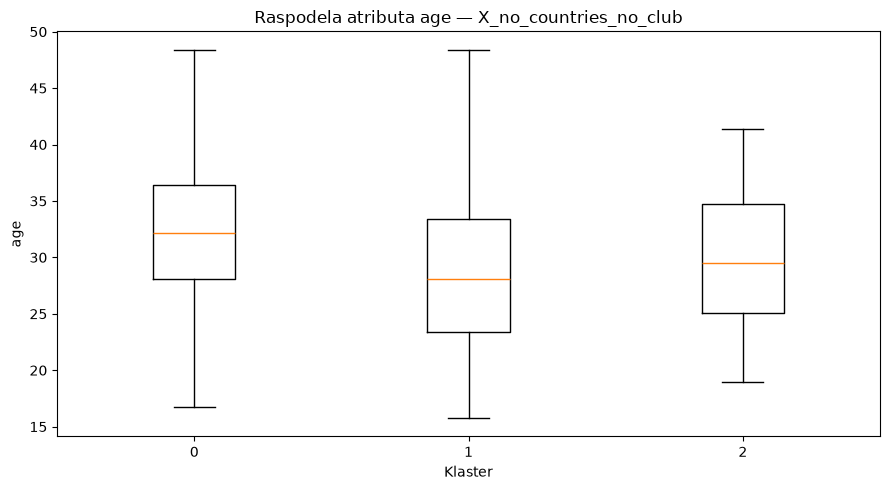

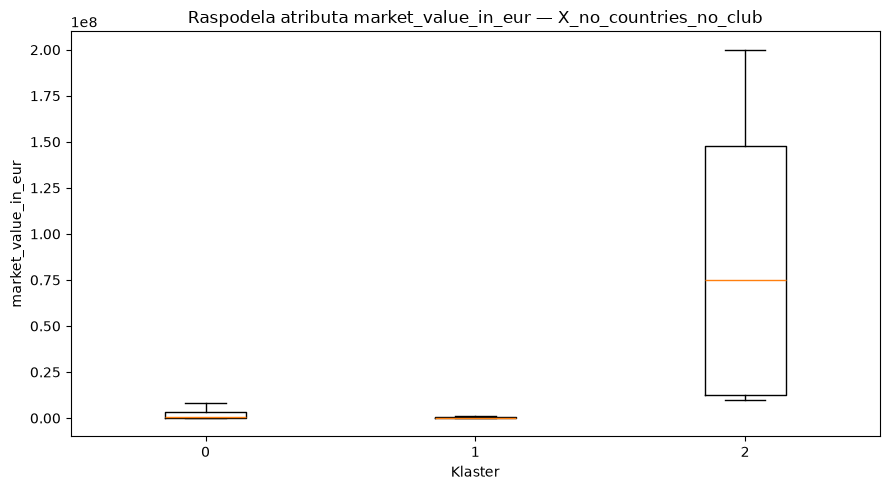

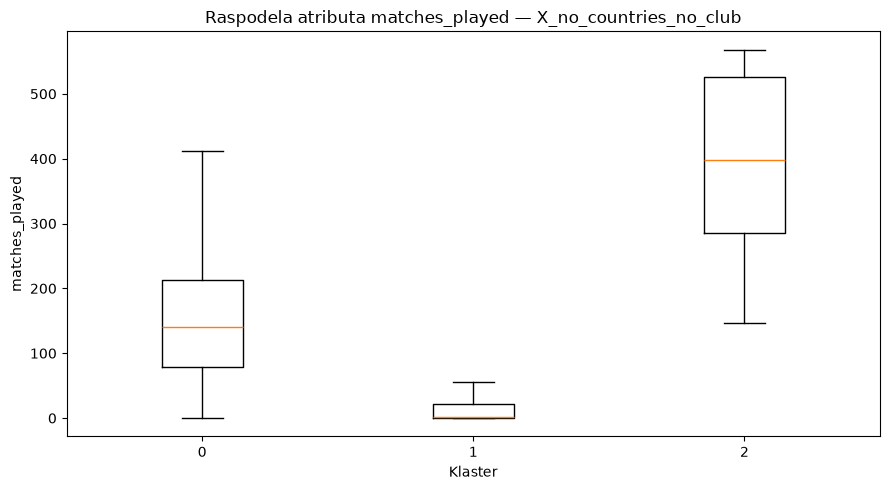

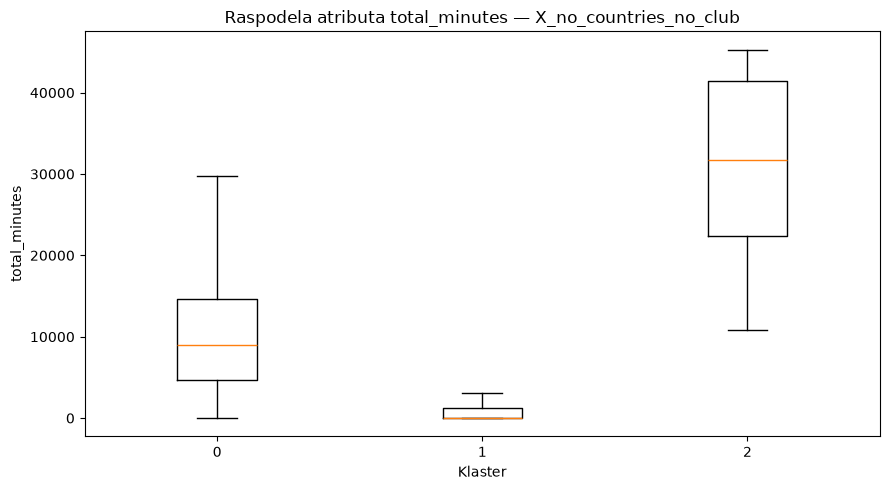

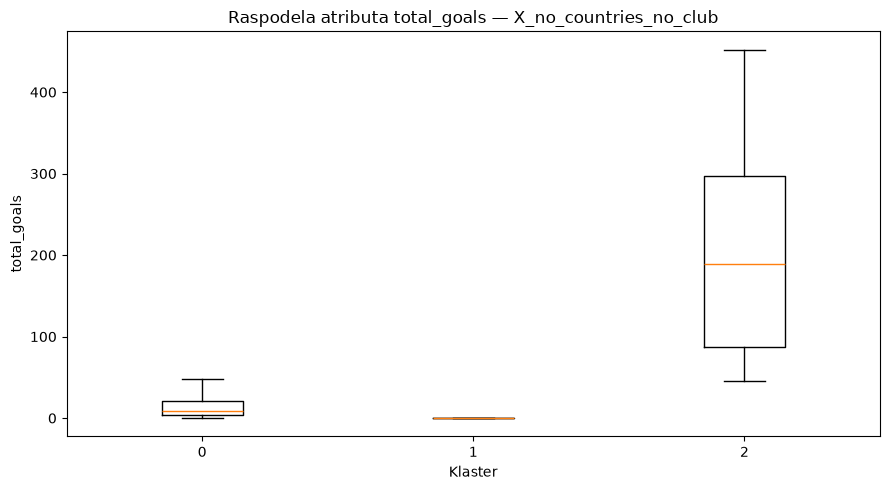

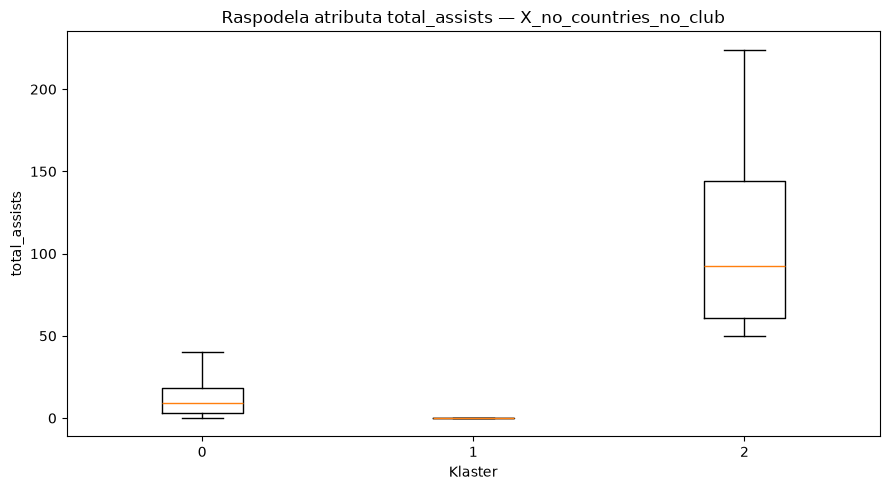


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,1551,15.510,32.268,181.443,11.317,1.373,"4,826,489.362","11,966,199.226",153.638,"10,450.804",26.469,17.344,13.607,110.596,65.905,9.640,25.044,"803,671.825","4,826,489.362","4,022,817.537",Midfield,Central Midfield,right,France,Spain
1,1,8439,84.390,29.042,182.321,1.782,0.132,"599,722.123","1,266,267.923",20.060,"1,399.293",11.948,1.122,0.984,16.419,16.023,1.330,11.576,"159,809.812","599,722.123","439,912.312",Defender,Centre-Back,right,Brazil,Brazil
2,2,10,0.100,30.080,182.000,98.800,53.700,"88,900,000.000","163,000,000.000",395.000,"31,246.700",22.083,214.700,112.400,333.800,58.700,33.200,34.100,"6,622,500.000","88,900,000.000","82,277,500.000",Attack,Right Winger,left,England,Belgium


In [27]:
result_X_no_countries_no_club = (
    run_best_clustering_and_analysis(
        X=X_no_countries_no_club,
        players_df=players_analysis,
        dataset_name="X_no_countries_no_club",
        algorithm="hierarchical"
    )
)


Pokretanje skupa: X_no_countries_no_club_pca95
Algoritam: hierarchical
Broj klastera: 3
Dimenzije uzorka: (10000, 55)
ANALIZA SKUPA: X_no_countries_no_club_pca95

Veličine klastera:


,broj_igraca,udeo_igraca
cluster,,
0,8943,89.430
1,102,1.020
2,955,9.550


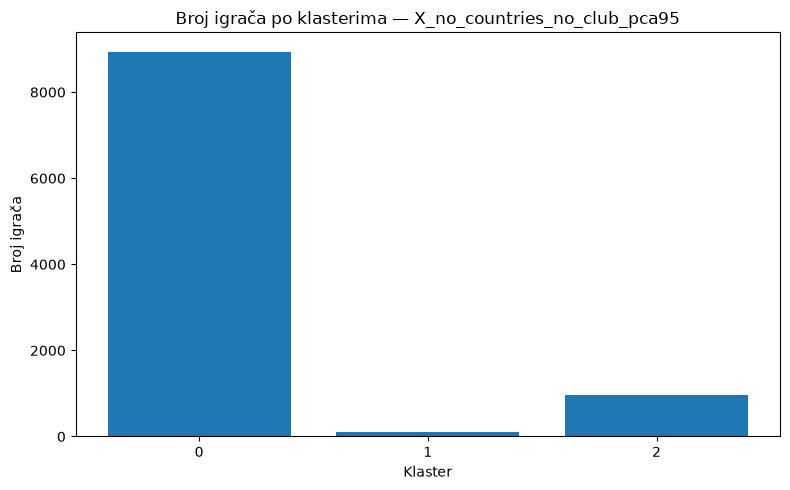


Prosečne vrednosti atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,29.189,182.181,2.234,0.185,"627,467.293","1,488,894.666",24.510,"1,700.149",12.693,1.395,1.441,19.661,17.915,1.563,12.149,"170,771.553","627,467.293","456,695.740"
1,29.988,183.343,49.922,11.794,"30,340,686.275","62,441,176.471",315.304,"22,736.353",25.898,67.922,42.167,238.892,89.235,20.647,30.863,"1,140,931.373","30,340,686.275","29,199,754.902"
2,32.812,182.095,8.910,0.969,"4,952,617.801","11,718,769.634",167.724,"11,315.981",27.164,20.014,13.974,118.576,71.939,10.915,26.260,"1,065,727.749","4,952,617.801","3,886,890.052"



Medijane atributa po klasterima:


,age,height_in_cm,international_caps,international_goals,market_value_in_eur,highest_market_value_in_eur,matches_played,total_minutes,minutes_std,total_goals,total_assists,starter_count,substitute_count,captain_count,valuation_count,first_valuation,latest_valuation,valuation_growth
cluster,,,,,,,,,,,,,,,,,,
0,28.270,182.000,0.000,0.000,"200,000.000","450,000.000",2.000,81.000,0.000,0.000,0.000,4.000,8.000,0.000,11.000,"50,000.000","200,000.000","50,000.000"
1,29.900,185.000,34.500,4.000,"17,500,000.000","50,000,000.000",316.000,"22,144.000",26.460,39.500,29.000,235.000,78.500,2.000,31.000,"150,000.000","17,500,000.000","14,850,000.000"
2,32.700,183.000,1.000,0.000,"1,000,000.000","7,500,000.000",160.000,"10,346.000",28.889,14.000,11.000,110.000,64.000,0.000,27.000,"150,000.000","1,000,000.000","600,000.000"



Raspodela atributa 'position' po klasterima (%):


...

foot,Unknown,both,left,right
cluster,,,,
0,11.750,3.840,22.620,61.790
1,0.000,4.900,26.470,68.630
2,0.520,3.040,22.830,73.610



Raspodela atributa 'country_of_birth' po klasterima (%):


country_of_birth,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahrain,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,CSSR,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Cyprus,Czech Republic,DR Congo,Denmark,Dominica,Dominican Republic,East Germany (GDR),Ecuador,Egypt,England,Equatorial Guinea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Jugoslawien (SFR),Kazakhstan,Kenya,"Korea, South",Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Lithuania,Luxembourg,Macao,Macedonia,Madagascar,Malawi,Malaysia,Mali,Martinique,Mauritania,Mayotte,Mexico,Moldova,Monaco,Morocco,Mozambique,Netherlands,Netherlands Antilles,Neukaledonien,New Zealand,Nicaragua,Niger,Nigeria,Northern Ireland,Norway,Oman,Panama,Papua New Guinea,Paraguay,People's republic of the Congo,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Réunion,Saudi Arabia,Scotland,Senegal,Serbia,Serbia and Montenegro,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Spain,St. Lucia,Sudan,Suriname,Sweden,Switzerland,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,UdSSR,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Yugoslavia (Republic),Zaire,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.110,0.070,0.130,3.960,0.020,0.760,0.810,0.010,0.020,0.130,1.870,0.020,0.020,0.420,5.170,0.170,0.030,0.030,0.350,0.420,0.280,0.080,0.020,0.010,0.200,0.040,1.950,0.040,0.100,0.590,0.940,0.020,0.080,0.360,0.090,1.610,0.010,0.010,0.040,0.270,0.070,4.040,0.010,0.080,0.020,0.040,0.280,4.990,0.010,0.010,0.160,4.100,0.670,2.580,0.040,0.210,0.090,0.010,0.060,0.040,0.250,0.190,0.010,0.080,0.010,0.410,0.250,4.290,0.080,1.900,0.020,1.110,0.030,0.060,1.390,0.010,0.030,0.010,0.070,0.010,0.100,0.010,0.010,0.120,0.010,0.020,0.010,0.150,0.020,0.020,0.000,1.100,0.070,0.010,0.120,0.020,3.140,0.020,0.010,0.100,0.000,0.010,0.890,0.250,0.970,0.010,0.080,0.010,0.250,0.020,0.130,0.010,1.140,2.590,0.010,1.150,2.230,0.030,0.080,0.470,1.790,0.670,0.210,0.450,0.100,0.300,0.360,0.030,0.100,4.310,0.010,0.010,0.010,1.050,0.820,0.010,0.030,0.010,0.130,0.080,0.030,0.120,3.130,0.020,1.270,2.040,0.060,2.630,0.020,1.610,11.850,0.760,0.020,0.220,0.010,0.100,0.880,0.200,0.030,0.040
1,0.000,0.000,0.980,6.860,0.000,0.000,0.980,0.000,0.000,0.000,4.900,0.000,0.000,0.000,6.860,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,0.980,0.980,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.960,0.980,7.840,0.000,0.000,0.000,0.000,0.000,11.760,0.980,0.000,0.000,7.840,0.000,0.980,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6.860,0.000,0.000,0.000,4.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.980,0.000,1.960,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,3.920,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.980,0.000,0.980,0.000,0.000,0.000,8.820,0.000,0.000,0.000,0.000,2.940,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,1.960,0.000,0.000,0.000
2,0.000,0.100,0.100,3.870,0.000,0.210,1.050,0.000,0.000,0.000,3.560,0.100,0.000,0.210,6.390,0.100,0.000,0.000,0.420,0.940,0.310,0.310,0.000,0.100,0.310,0.000,0.630,0.100,0.000,0.940,1.050,0.000,0.100,0.310,0.000,2.720,0.000,0.000,0.000,0.100,0.310,7.020,0.000,0.100,0.000,0.000,0.210,10.680,0.100,0.210,0.100,5.650,0.840,2.410,0.210,0.210,0.630,0.000,0.000,


Raspodela atributa 'country_of_citizenship' po klasterima (%):


country_of_citizenship,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,Bahrain,Barbados,Belarus,Belgium,Benin,Bolivia,Bosnia-Herzegovina,Brazil,Bulgaria,Burkina Faso,Burundi,Cameroon,Canada,Cape Verde,Central African Republic,Chad,Chile,China,Colombia,Comoros,Congo,Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,DR Congo,Denmark,Dominican Republic,Ecuador,Egypt,El Salvador,England,Equatorial Guinea,Eritrea,Estonia,Ethiopia,Faroe Islands,Finland,France,French Guiana,Gabon,Georgia,Germany,Ghana,Greece,Grenada,Guadeloupe,Guinea,Guinea-Bissau,Guyana,Haiti,Honduras,Hungary,Iceland,Indonesia,Iran,Iraq,Ireland,Israel,Italy,Jamaica,Japan,Jordan,Kazakhstan,Kenya,"Korea, South",Kosovo,Kyrgyzstan,Latvia,Lebanon,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Madagascar,Malawi,Malaysia,Mali,Malta,Martinique,Mauritania,Mauritius,Mexico,Moldova,Montenegro,Montserrat,Morocco,Mozambique,Netherlands,Neukaledonien,New Caledonia,New Zealand,Niger,Nigeria,North Macedonia,Northern Ireland,Norway,Oman,Pakistan,Palestine,Panama,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Qatar,Romania,Russia,Rwanda,Saudi Arabia,Scotland,Senegal,Serbia,Seychelles,Sierra Leone,Slovakia,Slovenia,Somalia,South Africa,Southern Sudan,Spain,St. Kitts & Nevis,St. Lucia,Suriname,Sweden,Switzerland,Syria,Tajikistan,Tanzania,Thailand,The Gambia,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Türkiye,Uganda,Ukraine,United Arab Emirates,United States,Unknown,Uruguay,Uzbekistan,Venezuela,Vietnam,Wales,Zambia,Zimbabwe
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.360,0.280,0.180,0.030,3.870,0.090,0.020,1.170,0.860,0.090,0.020,0.010,0.270,2.780,0.070,0.030,0.620,5.370,0.170,0.130,0.070,0.450,0.350,0.190,0.080,0.010,0.210,0.080,2.400,0.030,0.160,0.100,0.640,1.330,0.020,0.160,0.100,1.170,0.360,2.810,0.020,0.300,0.090,0.010,3.470,0.060,0.010,0.100,0.010,0.070,0.290,3.760,0.020,0.030,0.230,3.230,0.810,3.090,0.030,0.060,0.220,0.120,0.030,0.110,0.060,0.300,0.270,0.020,0.080,0.030,0.660,0.290,4.450,0.130,2.050,0.020,0.030,0.020,1.600,0.280,0.010,0.060,0.010,0.040,0.020,0.010,0.110,0.040,0.080,0.020,0.010,0.390,0.020,0.080,0.030,0.010,1.150,0.090,0.260,0.020,0.540,0.030,3.150,0.010,0.000,0.180,0.040,1.240,0.230,0.210,1.310,0.020,0.020,0.010,0.080,0.010,0.280,0.130,0.030,1.360,2.720,0.030,1.400,3.320,0.060,1.190,2.270,0.860,1.910,0.010,0.100,0.400,0.460,0.020,0.090,0.010,4.230,0.020,0.010,0.120,1.620,0.890,0.010,0.010,0.020,0.010,0.250,0.100,0.080,0.230,3.560,0.010,1.540,0.080,3.820,0.010,1.430,0.690,0.780,0.060,0.220,0.010,0.220,0.060,0.020
1,0.000,0.000,0.000,0.000,5.880,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,4.900,0.000,0.000,0.980,6.860,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,0.000,1.960,2.940,0.000,0.000,0.000,0.000,0.980,0.000,0.000,1.960,0.980,0.000,5.880,0.000,0.000,0.000,0.000,0.000,0.000,9.800,0.000,0.000,0.000,7.840,0.000,0.980,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,0.000,0.000,7.840,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,1.960,0.000,2.940,0.000,4.900,0.000,0.000,0.000,0.000,0.980,0.000,0.000,2.940,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,4.900,0.000,0.000,0.000,0.000,0.000,0.980,0.000,1.960,0.000,0.000,0.980,0.000,0.000,0.000,0.000,7.840,0.000,0.000,0.000,0.000,1.960,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.980,0.000,0.000,0.000,0.980,0.000,0.000
2,0.310,0.630,0.310,0.000,3.560,0.000,0.000,0.210,0.940,0.000,0.000,0.000,0.210,3.350,0.100,0.000,0.630,5.970,0.100,0.100,0.000,1.050,0.310,0.310,0.000,0.000,0.420,0.000,0.630,0.210,0.210,0.100,1.050,1.470,0.000,0.310,0.000,0.630,0.940,2.930,0.100,0.100,0.310,0.000

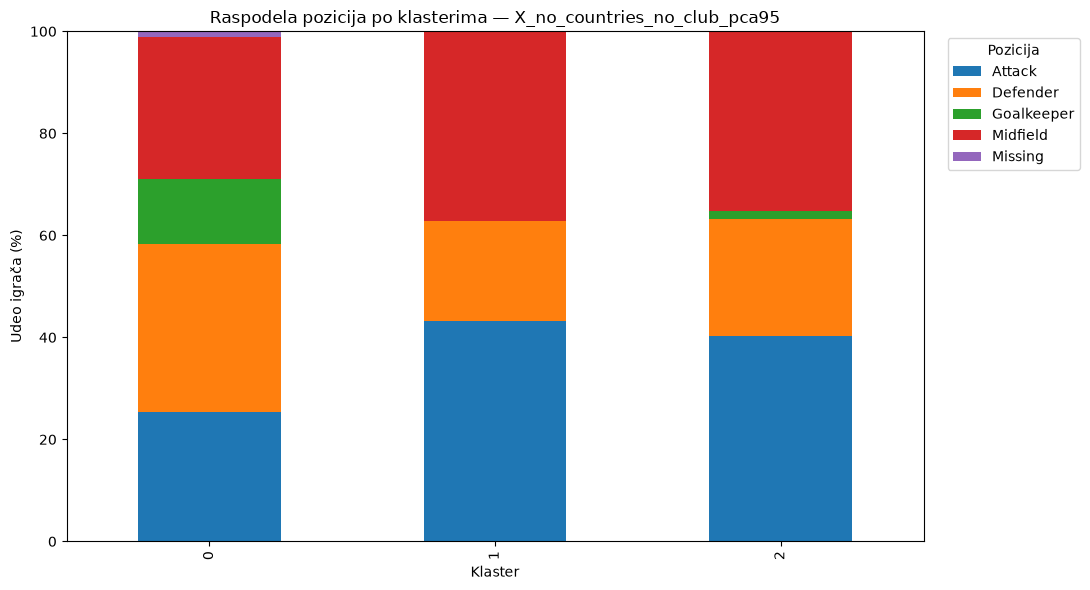

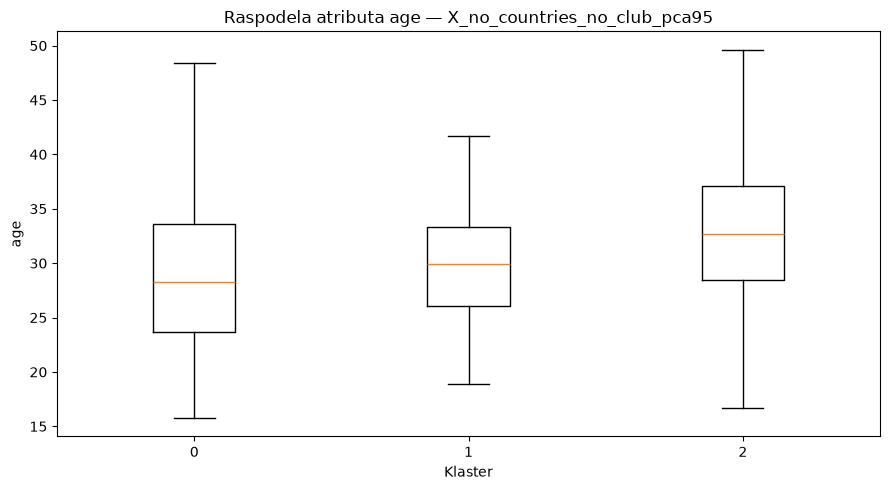

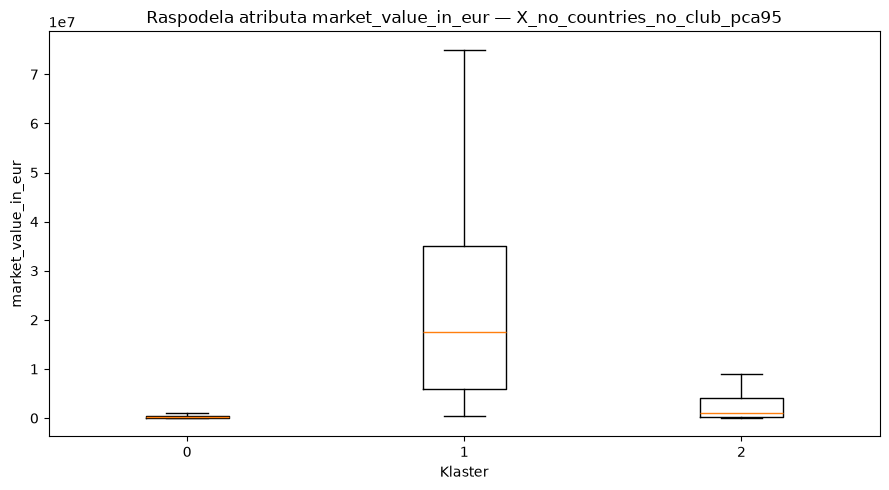

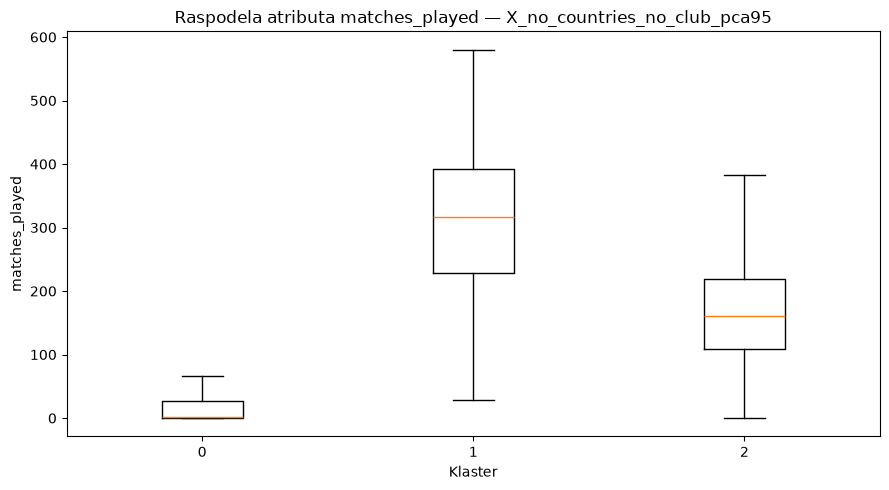

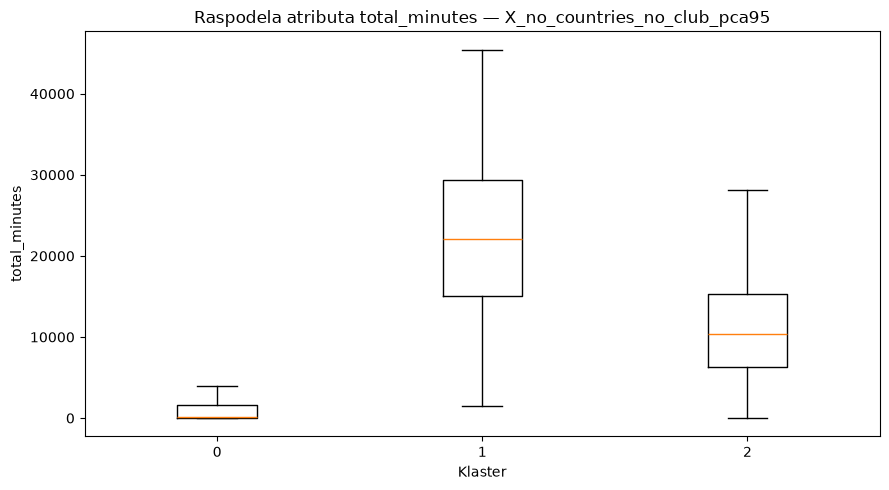

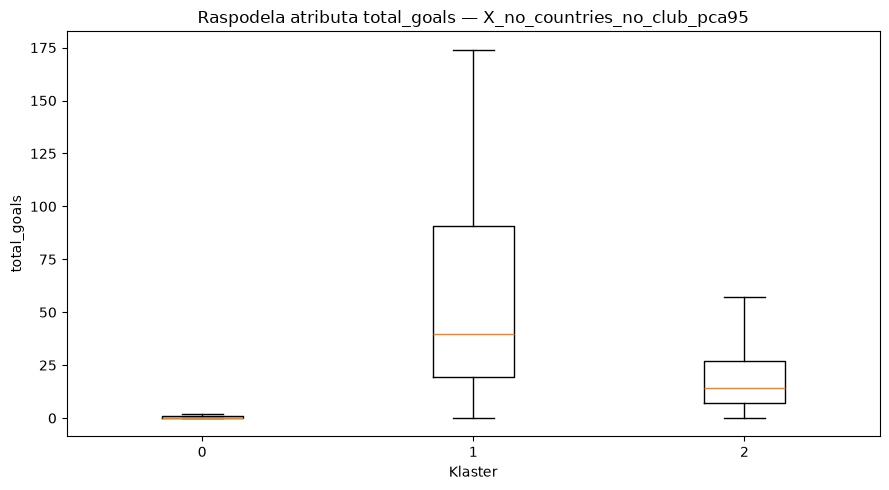

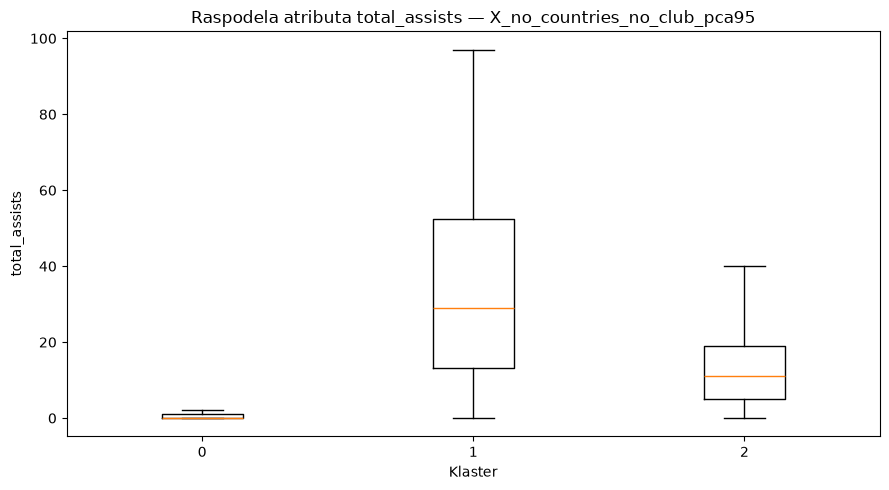


Sažetak klastera:


,cluster,broj_igraca,udeo_igraca,mean_age,mean_height_in_cm,mean_international_caps,mean_international_goals,mean_market_value_in_eur,mean_highest_market_value_in_eur,mean_matches_played,mean_total_minutes,mean_minutes_std,mean_total_goals,mean_total_assists,mean_starter_count,mean_substitute_count,mean_captain_count,mean_valuation_count,mean_first_valuation,mean_latest_valuation,mean_valuation_growth,najcesci_position,najcesci_sub_position,najcesci_foot,najcesci_country_of_birth,najcesci_country_of_citizenship
0,0,8943,89.430,29.189,182.181,2.234,0.185,"627,467.293","1,488,894.666",24.510,"1,700.149",12.693,1.395,1.441,19.661,17.915,1.563,12.149,"170,771.553","627,467.293","456,695.740",Defender,Centre-Back,right,Brazil,Brazil
1,1,102,1.020,29.988,183.343,49.922,11.794,"30,340,686.275","62,441,176.471",315.304,"22,736.353",25.898,67.922,42.167,238.892,89.235,20.647,30.863,"1,140,931.373","30,340,686.275","29,199,754.902",Attack,Centre-Forward,right,France,France
2,2,955,9.550,32.812,182.095,8.910,0.969,"4,952,617.801","11,718,769.634",167.724,"11,315.981",27.164,20.014,13.974,118.576,71.939,10.915,26.260,"1,065,727.749","4,952,617.801","3,886,890.052",Attack,Centre-Forward,right,France,Spain


In [28]:
result_X_no_countries_no_club_pca95 = (
    run_best_clustering_and_analysis(
        X=X_no_countries_no_club_pca95,
        players_df=players_analysis,
        dataset_name="X_no_countries_no_club_pca95",
        algorithm="hierarchical"
    )
)